#**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

!pip install -q mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

#**Import Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving My_DiseasePrediction_Dataset.csv to My_DiseasePrediction_Dataset.csv


In [3]:
df = pd.read_csv('dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


#**(1) Data Overview**

In [4]:
# ============================================================
# 2. INITIAL DATA OVERVIEW
# ============================================================

print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== COLUMN NAMES ==========")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== FIRST 5 ROWS ==========")
display(df.head(5))

print("\n========== LAST 5 ROWS ==========")
display(df.tail(5))

print("\n========== RANDOM SAMPLE ==========")
display(df.sample(10, random_state=42))

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== NUMERICAL STATISTICS ==========")
display(df.describe().T)

print("\n========== CATEGORICAL STATISTICS ==========")
display(df.describe(include="object").T)


========== DATASET SHAPE ==========
Rows: 50000
Columns: 37

========== COLUMN NAMES ==========
1. age_level
2. gender
3. bmi_level
4. smoking
5. diabetes
6. age
7. age_normalized
8. bmi
9. hypertension
10. heart_disease
11. HbA1c_level
12. glucose
13. cholesterol
14. sleep_hours
15. triglycerides
16. physical_activity
17. family_history
18. stress_level
19. low_hdl_cholesterol
20. high_ldl_cholesterol
21. blood_pressure
22. high_blood_pressure
23. sugar_consumption
24. crp_level
25. homocysteine_level
26. systolic_bp
27. diastolic_bp
28. alcohol_intake
29. salt_intake
30. heart_rate
31. hdl
32. ldl
33. education_level
34. employment_status
35. disease_flags
36. sublabel
37. label

========== DATA TYPES ==========
age_level                object
gender                   object
bmi_level                object
smoking                  object
diabetes                 object
age                     float64
age_normalized          float64
bmi                     float64
hypertension       

,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,...,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,disease_flags,sublabel,label
0,Young,Male,Underweight,Never,No,6.0,0.045977,16.7,0.000000,0.000000,...,NaN,8.38794,74.120603,65.713568,131.542714,Tertiary,Employed,"0,0,0",N,Normal
1,Mature,Female,Overweight,Former,No,60.0,0.666666,26.1,0.077392,0.028032,...,14.1,5.00000,83.000000,72.000000,NaN,Primary,Employed,"0,0,0",N,Normal
2,Mature,Female,Obese,Never,No,46.0,0.505747,35.9,0.136603,0.020737,...,8.7,3.60000,71.000000,96.000000,125.000000,Secondary,Unemployed,"0,0,1",HY,Abnormal
3,Mature,Female,Overweight,Current,Yes,51.0,0.563218,26.7,0.200000,0.080000,...,18.6,11.40000,60.000000,78.000000,137.000000,Primary,Retired,"1,0,1",DI_HY,Abnormal
4,Middle,NaN,Normal,Never,No,42.0,0.459770,21.8,0.004258,0.001703,...,NaN,6.60000,52.000000,40.000000,170.000000,Tertiary,Unemployed,"0,0,0",N,Normal



========== LAST 5 ROWS ==========


,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,...,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,disease_flags,sublabel,label
49995,Mature,Female,Obese,Current,No,61.0,0.678160,31.00,0.122538,0.052516,...,4.8,11.800000,92.000000,85.00000,158.000000,Tertiary,Retired,NaN,N,Normal
49996,Mature,Female,NaN,Never,Yes,62.0,0.689655,19.20,0.173077,0.096154,...,16.2,12.900000,73.000000,59.00000,109.000000,Primary,Retired,"1,0,1",DI_HY,Abnormal
49997,Mature,Male,Overweight,NaN,No,62.0,0.689655,26.70,0.082188,0.056899,...,16.5,12.500000,79.000000,72.00000,162.000000,NaN,Employed,"0,0,1",HY,Abnormal
49998,Senior,Female,Overweight,Never,Yes,73.0,0.816091,29.10,0.277344,0.167969,...,3.8,3.900000,59.000000,53.00000,82.000000,NaN,Employed,"1,0,1",DI_HY,Abnormal
49999,Middle,Female,Normal,Never,No,45.0,0.494253,23.72,0.000000,0.000000,...,NaN,8.572797,74.698888,64.64414,130.244654,Tertiary,Unemployed,"0,0,0",N,Normal



========== RANDOM SAMPLE ==========


,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,...,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,disease_flags,sublabel,label
33553,Middle,Female,Obese,Current,No,24.0,0.252873,30.200000,0.057722,0.007800,...,18.000000,9.300000,58.000000,30.000000,150.000000,Tertiary,Unemployed,"0,0,1",HY,Abnormal
9427,Mature,Male,Normal,Never,No,NaN,0.528736,23.660000,0.000000,0.000000,...,15.040035,8.527104,74.580159,65.636847,129.283437,Primary,Unemployed,"0,0,0",N,Normal
199,Senior,Female,Overweight,Never,No,79.0,0.885057,29.000000,0.165398,0.084179,...,17.400000,NaN,92.000000,44.000000,82.000000,Secondary,Employed,"0,0,1",HY,Abnormal
12447,Mature,Female,Normal,Never,No,47.0,0.517241,20.900000,0.056694,0.010903,...,9.900000,6.900000,93.000000,46.000000,110.000000,Primary,Unemployed,"0,0,1",HY,Abnormal
39489,Senior,Male,Normal,Former,NaN,NaN,0.827586,24.910000,0.000000,1.000000,...,15.635225,8.480217,74.271285,64.383973,129.404007,Primary,Employed,"0,1,0",HT,Abnormal
42724,Middle,NaN,Obese,Never,No,41.0,0.448276,39.760296,0.048572,0.003610,...,14.734602,8.507951,74.937850,63.691489,127.488802,Tertiary,Unemployed,"0,0,0",N,Normal
10822,Senior,Male,Overweight,Former,No,78.0,0.873563,27.320000,1.000000,1.000000,...,14.947588,8.490022,73.303728,64.480263,NaN,Tertiary,Employed,"0,1,1",HT_HY,Abnormal
49498,Mature,Female,Normal,Never,Yes,64.0,0.712643,20.600000,0.173077,0.096154,...,9.200000,9.400000,56.000000,54.000000,179.000000,Secondary,Employed,"1,0,0",DI,Abnormal
4144,Senior,Male,Obese,Current,No,70.0,0.781609,32.800000,0.217391,0.130435,...,23.800000,7.000000,82.000000,53.000000,124.000000,Primary,Unemployed,"0,0,1",HY,Abnormal
36958,Middle,Male,Overweight,Never,No,41.0,0.448275,25.400000,0.025517,0.003492,...,7.200000,11.300000,93.000000,62.000000,160.000000,Tertiary,NaN,"0,0,1",HY,Abnormal



========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age_level             47454 non-null  object 
 1   gender                47537 non-null  object 
 2   bmi_level             47535 non-null  object 
 3   smoking               47581 non-null  object 
 4   diabetes              47477 non-null  object 
 5   age                   47480 non-null  float64
 6   age_normalized        47456 non-null  float64
 7   bmi                   47574 non-null  float64
 8   hypertension          47470 non-null  float64
 9   heart_disease         47551 non-null  float64
 10  HbA1c_level           47518 non-null  float64
 11  glucose               47475 non-null  float64
 12  cholesterol           47488 non-null  float64
 13  sleep_hours           47456 non-null  float64
 14  triglycerides         47582

,count,mean,std,min,25%,50%,75%,max
age,47480.0,49.617713,21.700483,2.000000,32.000000,50.000000,67.000000,89.000000
age_normalized,47456.0,0.547104,0.249709,0.000000,0.344827,0.551724,0.747126,1.000000
bmi,47574.0,27.465168,7.050024,10.300000,22.100000,27.320000,32.600000,95.220000
hypertension,47470.0,0.128014,0.188453,0.000000,0.000000,0.066946,0.206983,1.000000
heart_disease,47551.0,0.073470,0.138907,0.000000,0.000000,0.007299,0.115053,1.000000
HbA1c_level,47518.0,5.942298,0.956258,3.500000,5.384805,5.800000,6.861842,9.000000
glucose,47475.0,135.396151,38.634827,70.000000,100.000000,138.000000,160.000000,300.000000
cholesterol,47488.0,223.879431,35.610284,150.000000,201.000000,225.000000,242.000000,300.000000
sleep_hours,47456.0,6.958628,1.428149,4.000000,6.200000,6.985444,7.700000,10.000000
triglycerides,47582.0,179.318756,67.507809,50.000000,129.000000,179.000000,243.000000,400.000000



========== CATEGORICAL STATISTICS ==========


,count,unique,top,freq
age_level,47454,4,Mature,14841
gender,47537,2,Female,25053
bmi_level,47535,4,Obese,16558
smoking,47581,3,Never,21827
diabetes,47477,2,No,30442
physical_activity,47535,3,High,20418
family_history,47558,2,No,26655
stress_level,47475,3,High,17187
low_hdl_cholesterol,47509,2,No,38098
high_ldl_cholesterol,47513,2,Yes,24746


In [5]:
# ============================================================
# DATASET KNOWLEDGE PRESENTATION
# ============================================================

dataset_knowledge = pd.DataFrame({
    "Attribute": [
        "age_level",
        "gender",
        "bmi_level",
        "smoking",
        "diabetes",
        "age",
        "age_normalized",
        "bmi",
        "hypertension",
        "heart_disease",
        "HbA1c_level",
        "glucose",
        "cholesterol",
        "sleep_hours",
        "triglycerides",
        "physical_activity",
        "family_history",
        "stress_level",
        "low_hdl_cholesterol",
        "high_ldl_cholesterol",
        "blood_pressure",
        "high_blood_pressure",
        "sugar_consumption",
        "crp_level",
        "homocysteine_level",
        "systolic_bp",
        "diastolic_bp",
        "alcohol_intake",
        "salt_intake",
        "heart_rate",
        "hdl",
        "ldl",
        "education_level",
        "employment_status",
        "disease_flags",
        "sublabel",
        "label"
    ],

    "Description": [
        "Categorical age group",
        "Gender of the individual",
        "Categorical BMI group",
        "Smoking status",
        "Diabetes status",
        "Age in years",
        "Normalized representation of age",
        "Body Mass Index",
        "Hypertension status",
        "Heart disease status",
        "HbA1c measurement",
        "Blood glucose level",
        "Total cholesterol level",
        "Average sleep duration",
        "Triglyceride level",
        "Physical activity level",
        "Family history information",
        "Stress level",
        "Indicator of low HDL cholesterol",
        "Indicator of high LDL cholesterol",
        "Blood pressure measurement",
        "High blood pressure indicator",
        "Sugar consumption level",
        "C-reactive protein level",
        "Homocysteine level",
        "Systolic blood pressure",
        "Diastolic blood pressure",
        "Alcohol consumption level",
        "Salt consumption level",
        "Heart rate",
        "HDL cholesterol level",
        "LDL cholesterol level",
        "Education level",
        "Employment status",
        "Encoded disease combination",
        "Multiclass disease category",
        "Binary normal/abnormal category"
    ],

    "Data_Type": df[[c for c in df.columns]].dtypes.astype(str).values
})

display(dataset_knowledge)

,Attribute,Description,Data_Type
0,age_level,Categorical age group,object
1,gender,Gender of the individual,object
2,bmi_level,Categorical BMI group,object
3,smoking,Smoking status,object
4,diabetes,Diabetes status,object
5,age,Age in years,float64
6,age_normalized,Normalized representation of age,float64
7,bmi,Body Mass Index,float64
8,hypertension,Hypertension status,float64
9,heart_disease,Heart disease status,float64


#Target Class Meaning

In [6]:
# DISEASE CLASS Meaning

class_meaning = {
    "N": "No Disease",
    "DI": "Diabetes",
    "HY": "Hypertension",
    "HT": "Heart Disease",
    "DI_HY": "Diabetes + Hypertension",
    "DI_HT": "Diabetes + Heart Disease",
    "HT_HY": "Heart Disease + Hypertension",
    "DI_HT_HY": "Diabetes + Heart Disease + Hypertension"
}

class_table = pd.DataFrame(
    list(class_meaning.items()),
    columns=["Class", "Meaning"]
)

display(class_table)

,Class,Meaning
0,N,No Disease
1,DI,Diabetes
2,HY,Hypertension
3,HT,Heart Disease
4,DI_HY,Diabetes + Hypertension
5,DI_HT,Diabetes + Heart Disease
6,HT_HY,Heart Disease + Hypertension
7,DI_HT_HY,Diabetes + Heart Disease + Hypertension


#**Missing Values**

In [8]:
print("========== MISSING VALUES ==========")

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

display(missing_summary)
print("\nTotal missing cells:", df.isnull().sum().sum())

========== MISSING VALUES ==========


,Missing Count,Missing Percentage
heart_rate,2593,5.186
age_level,2546,5.092
age_normalized,2544,5.088
sleep_hours,2544,5.088
label,2543,5.086
blood_pressure,2537,5.074
hypertension,2530,5.060
homocysteine_level,2530,5.060
stress_level,2525,5.050
glucose,2525,5.050



Total missing cells: 89657


#Missing Value Visualization

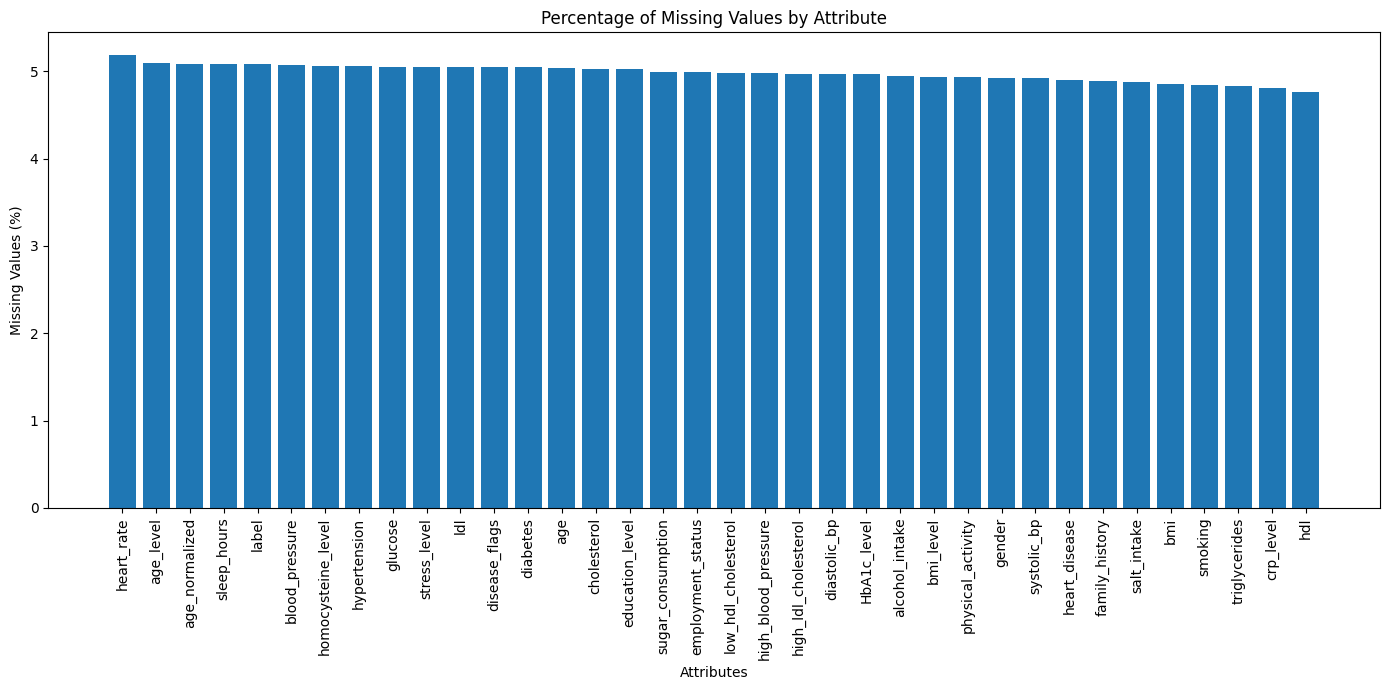

In [7]:
plt.figure(figsize=(14, 7))

missing_percentage_plot = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage_plot = missing_percentage_plot[
    missing_percentage_plot > 0
]

plt.bar(
    missing_percentage_plot.index,
    missing_percentage_plot.values
)

plt.xticks(rotation=90)
plt.ylabel("Missing Values (%)")
plt.xlabel("Attributes")
plt.title("Percentage of Missing Values by Attribute")
plt.tight_layout()
plt.show()

#**Duplicate Rows**

In [9]:
print("\n========== DUPLICATE CHECK ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)



========== DUPLICATE CHECK ==========
Number of duplicate rows: 6


#**Unique Values**

In [10]:
print("\n========== UNIQUE VALUES ==========")

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
})

display(unique_summary)


========== UNIQUE VALUES ==========


,Column,Unique Values
0,age_level,5
1,gender,3
2,bmi_level,5
3,smoking,4
4,diabetes,3
5,age,89
6,age_normalized,152
7,bmi,4722
8,hypertension,138
9,heart_disease,126


#**Exploratory Data Analysis-Raw Data Before Preprocessing**

#Target Class Distribution

In [11]:
print("========== TARGET DISTRIBUTION ==========")

target_distribution = df["sublabel"].value_counts()

print(target_distribution)

print("\nPercentage Distribution:")
print(
    (df["sublabel"].value_counts(normalize=True) * 100)
    .round(2))

========== TARGET DISTRIBUTION ==========
sublabel
N           19020
HY          12422
DI_HY       11828
DI           5679
HT            462
DI_HT         249
HT_HY         190
DI_HT_HY      150
Name: count, dtype: int64

Percentage Distribution:
sublabel
N           38.04
HY          24.84
DI_HY       23.66
DI          11.36
HT           0.92
DI_HT        0.50
HT_HY        0.38
DI_HT_HY     0.30
Name: proportion, dtype: float64


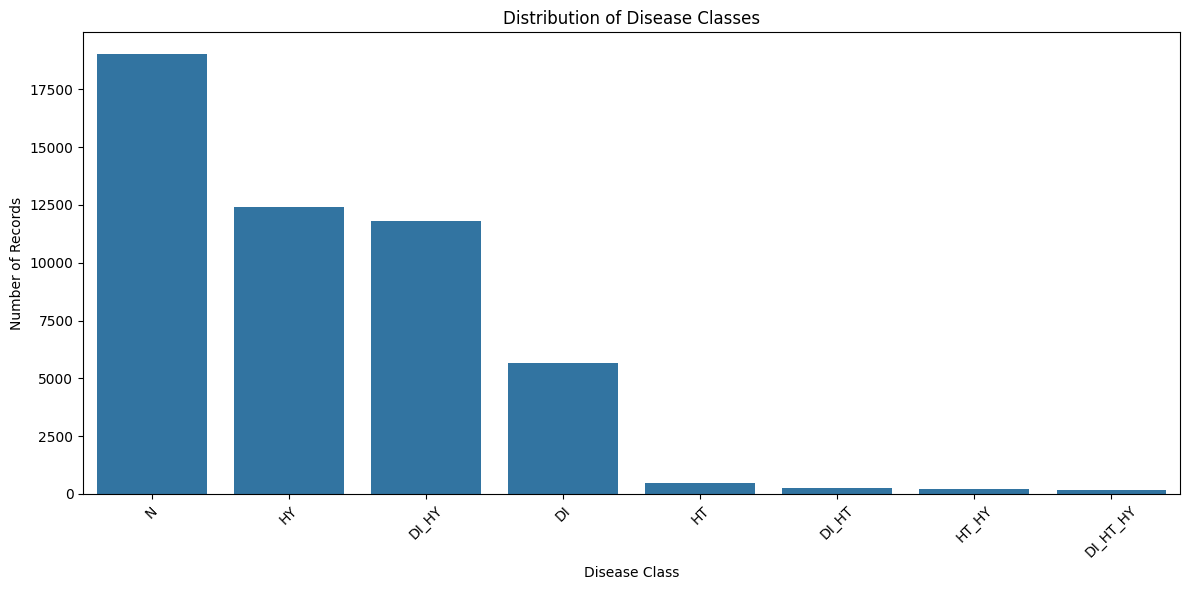

In [12]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="sublabel",
    order=df["sublabel"].value_counts().index
)

plt.title("Distribution of Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Disease Distribution By Gender

sublabel,DI,DI_HT,DI_HT_HY,DI_HY,HT,HT_HY,HY,N
gender,,,,,,,,
Female,2661,105,69,5629,178,77,6021,10313
Male,2740,129,74,5616,265,101,5800,7759


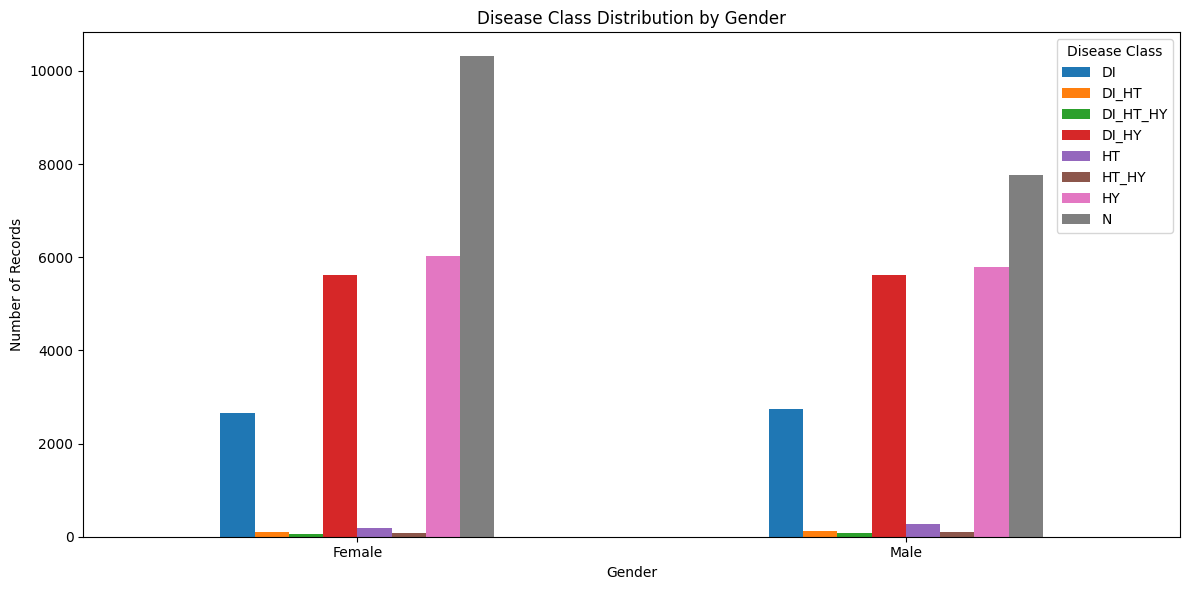

In [13]:
gender_disease = pd.crosstab(
    df["gender"],
    df["sublabel"]
)

display(gender_disease)

gender_disease.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Disease Class Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Disease Class")

plt.tight_layout()
plt.show()

#Numerical Feature Distribution

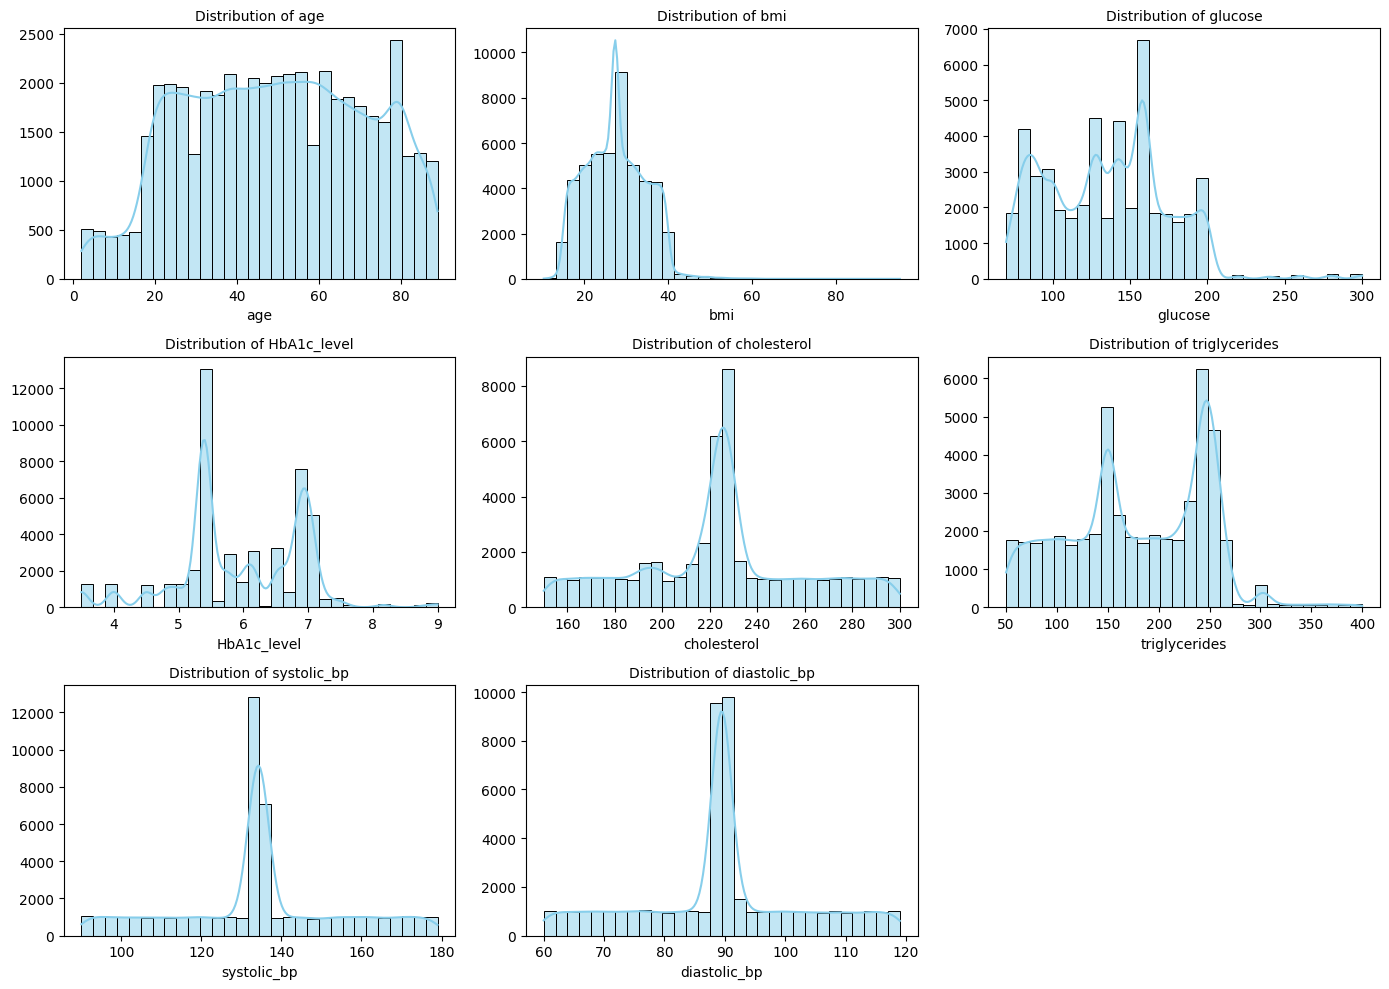

Numerical columns:
['age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']


In [14]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

#Key Numerical Features Distribution (Pre-Preprocessing)
numerical_columns = ['age', 'bmi', 'glucose', 'HbA1c_level','cholesterol', 'triglycerides', 'systolic_bp', 'diastolic_bp']
plt.figure(figsize=(14, 10))
for i, col in enumerate(numerical_columns, 1):
    if col in df.columns:
        plt.subplot(3, 3, i)
        sns.histplot(df[col], kde=True, color='skyblue', bins=30)
        plt.title(f'Distribution of {col}', fontsize=10)
        plt.xlabel(col)
        plt.ylabel('')
plt.tight_layout()
plt.show()
print("Numerical columns:")
print(numeric_columns)

#Categorical Feature Distribution

Categorical columns:
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status', 'disease_flags', 'sublabel', 'label']


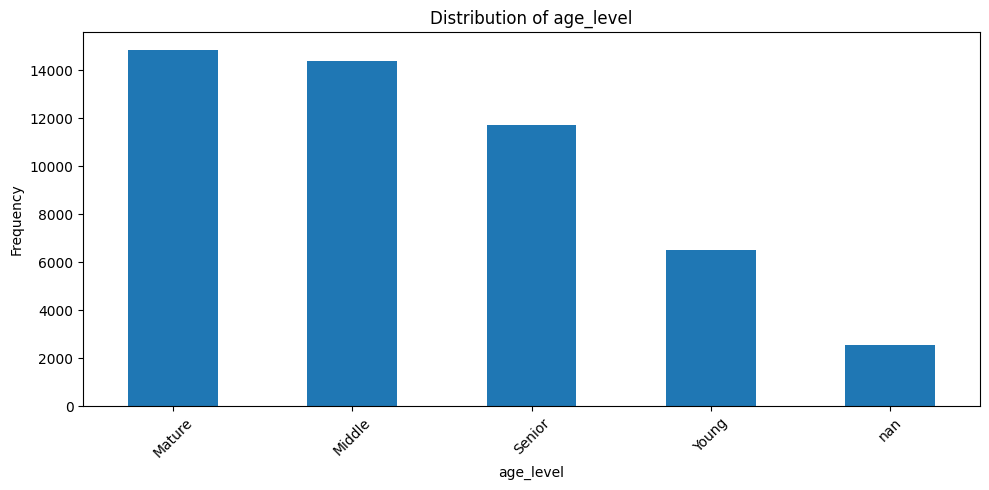

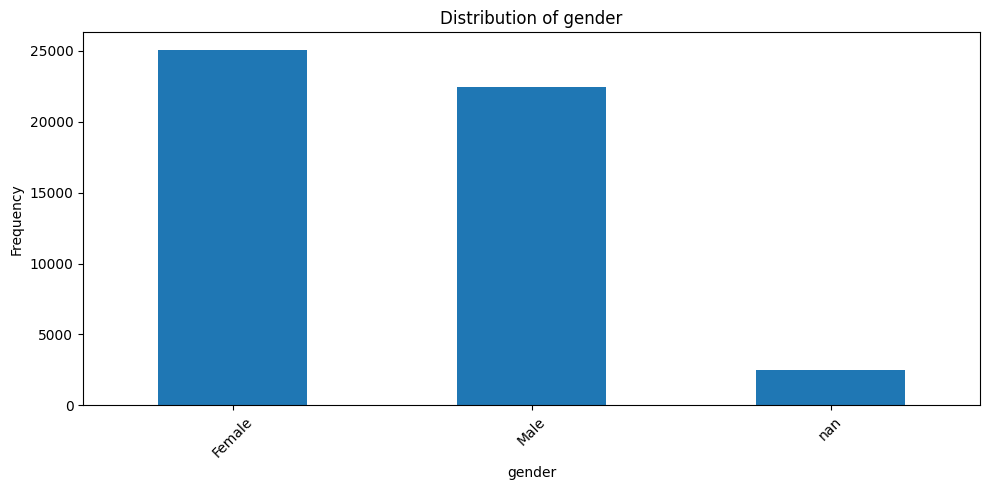

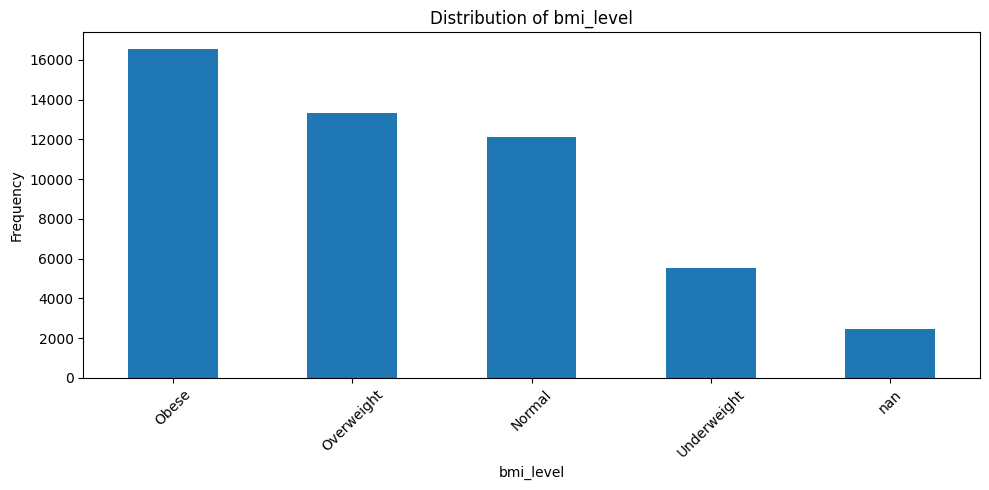

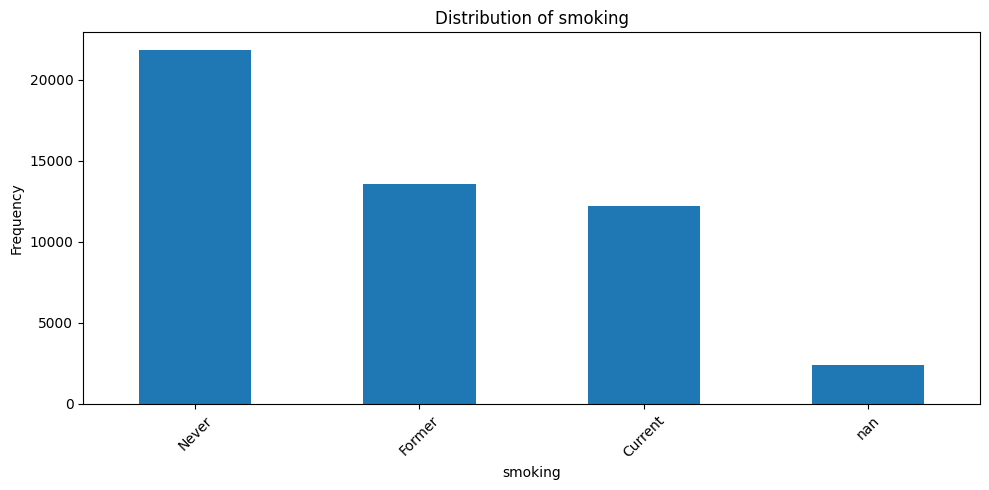

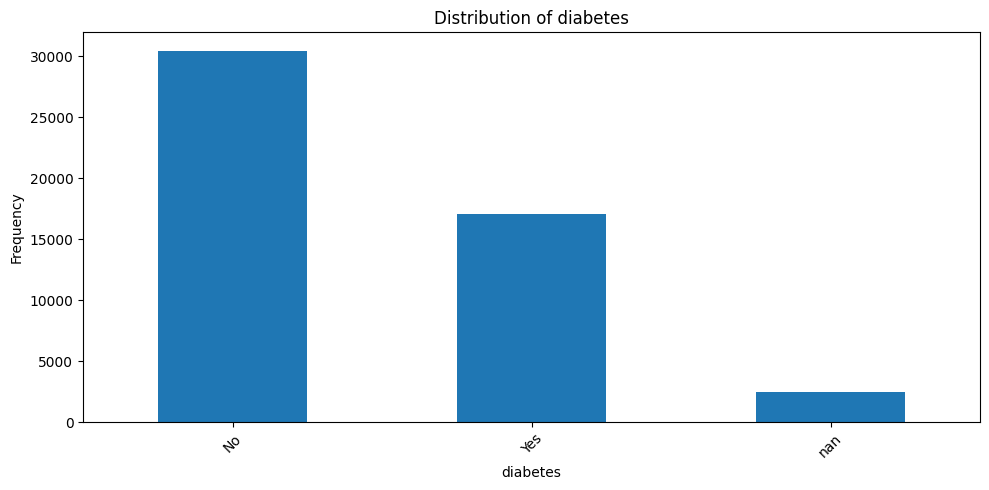

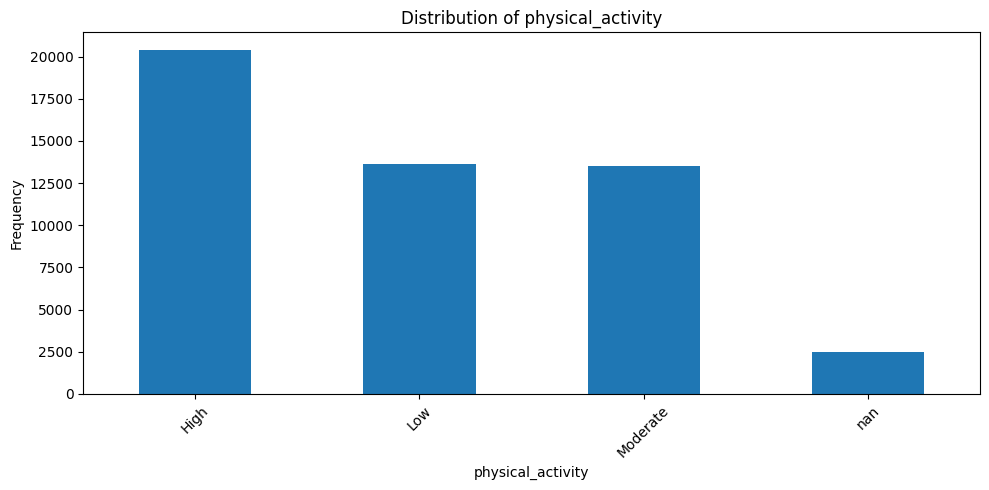

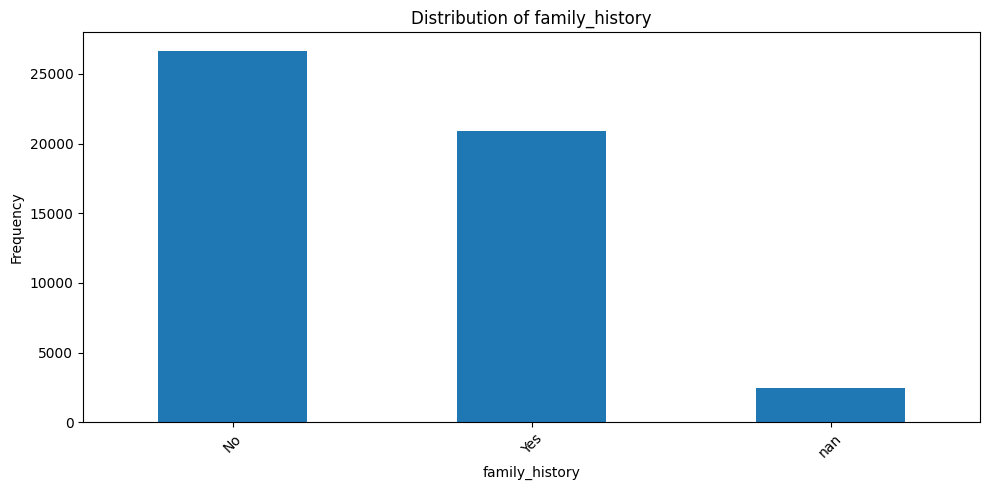

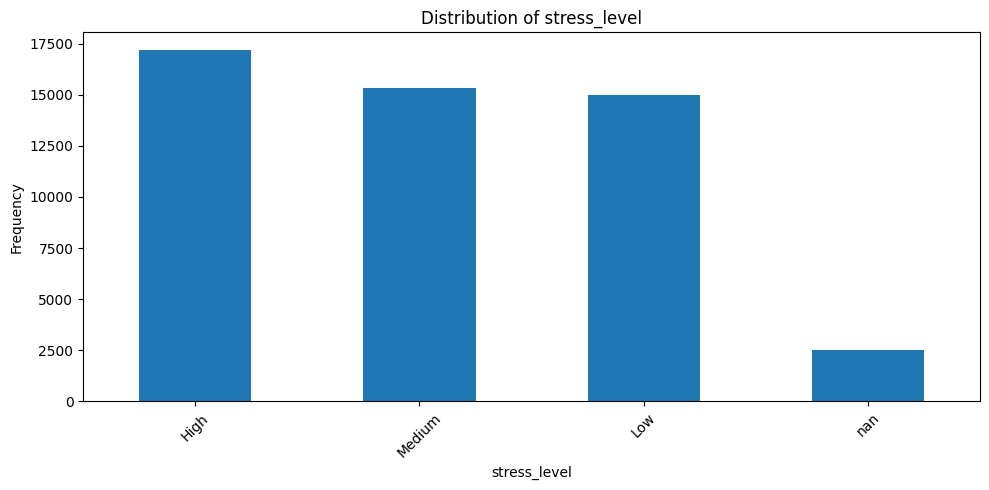

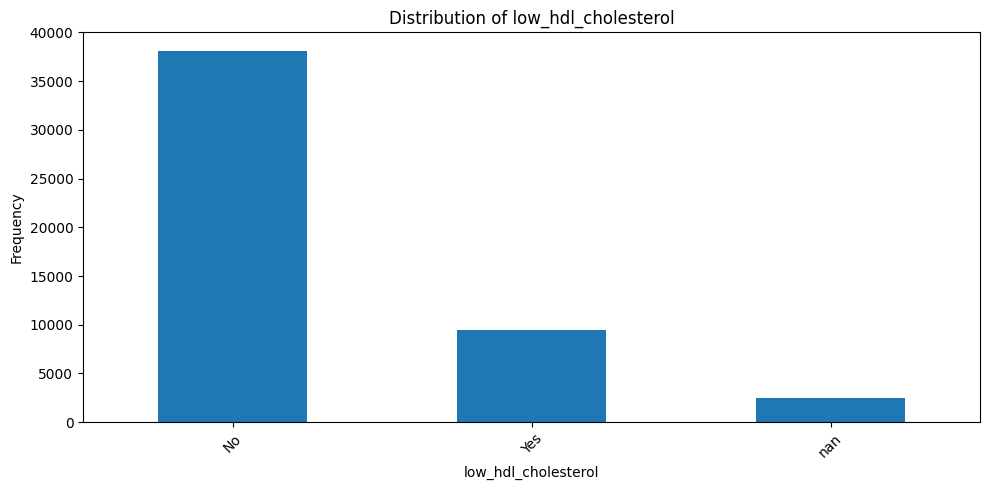

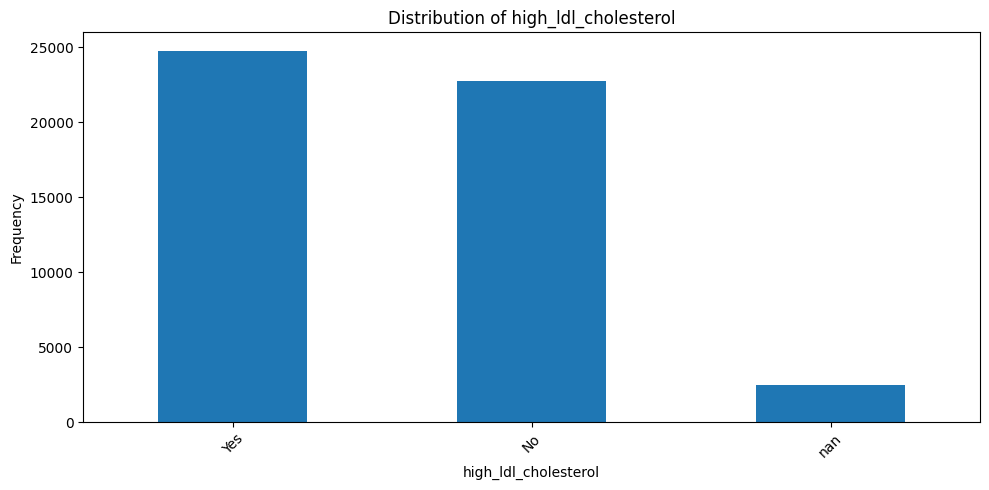

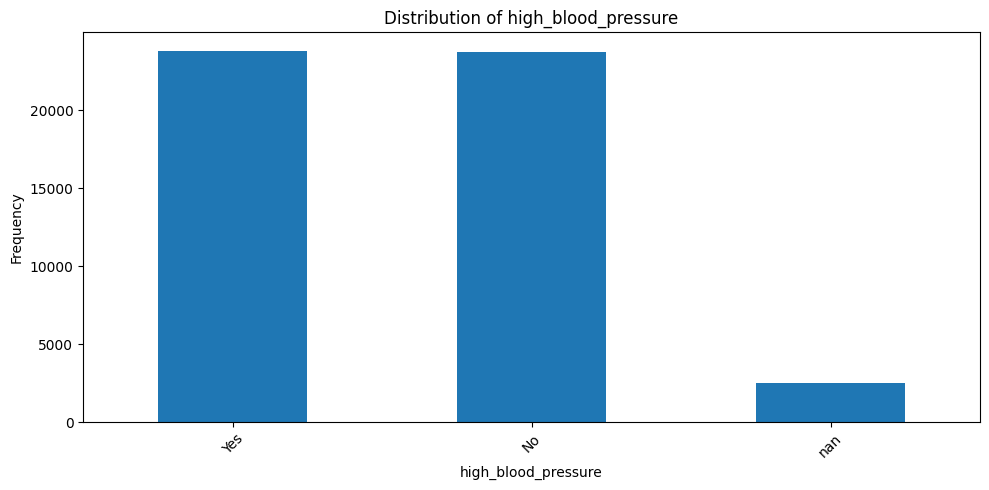

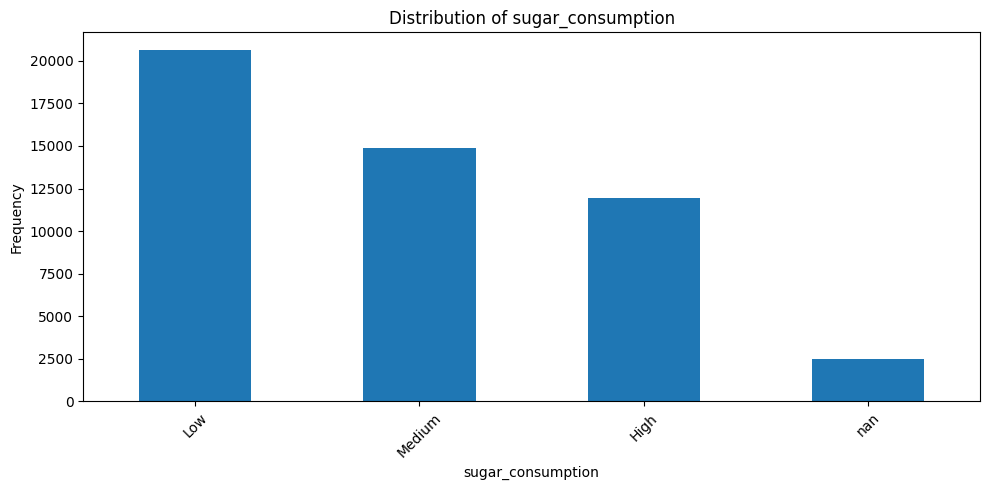

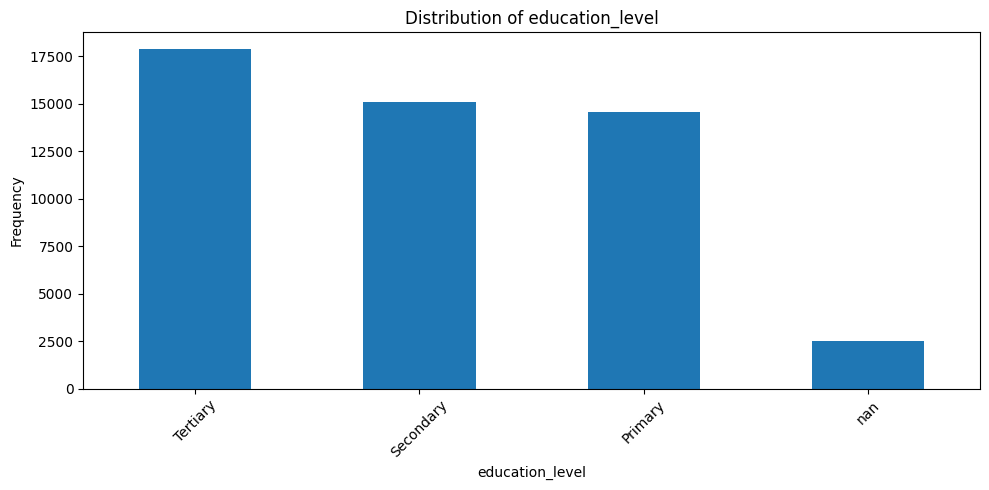

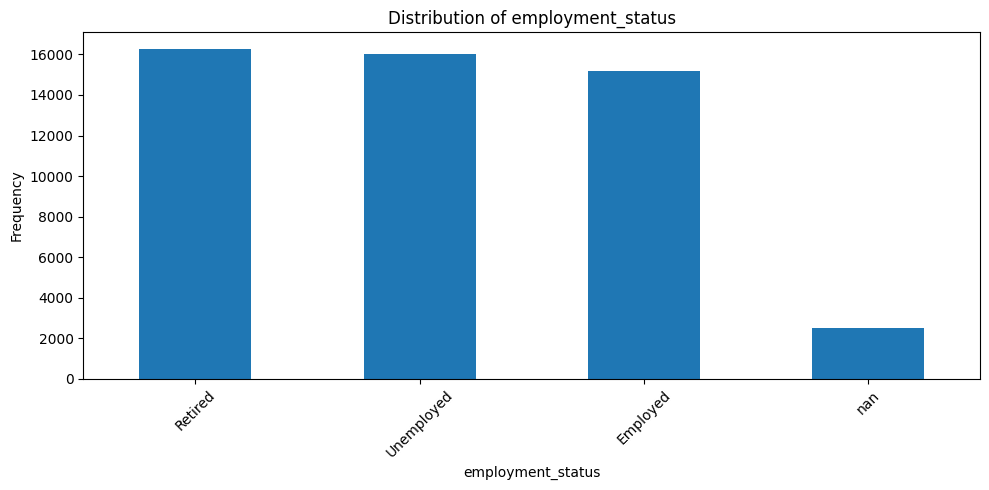

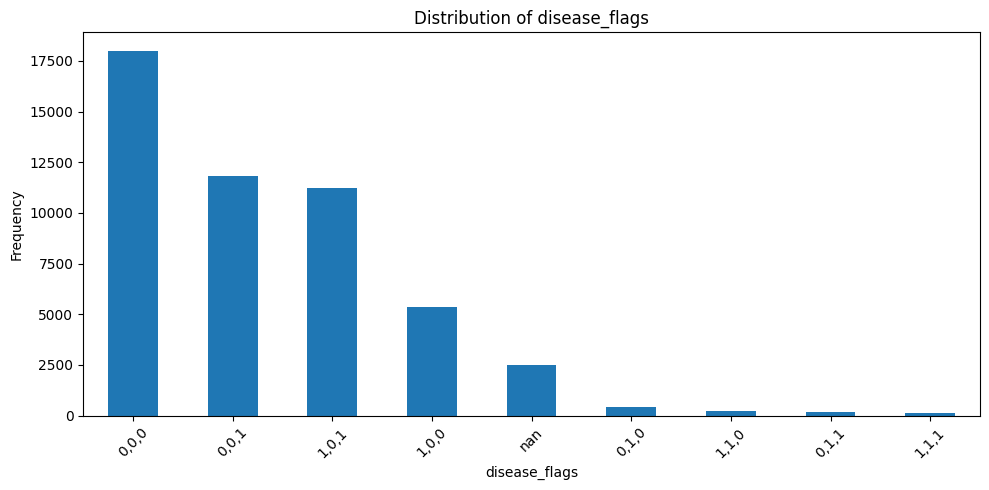

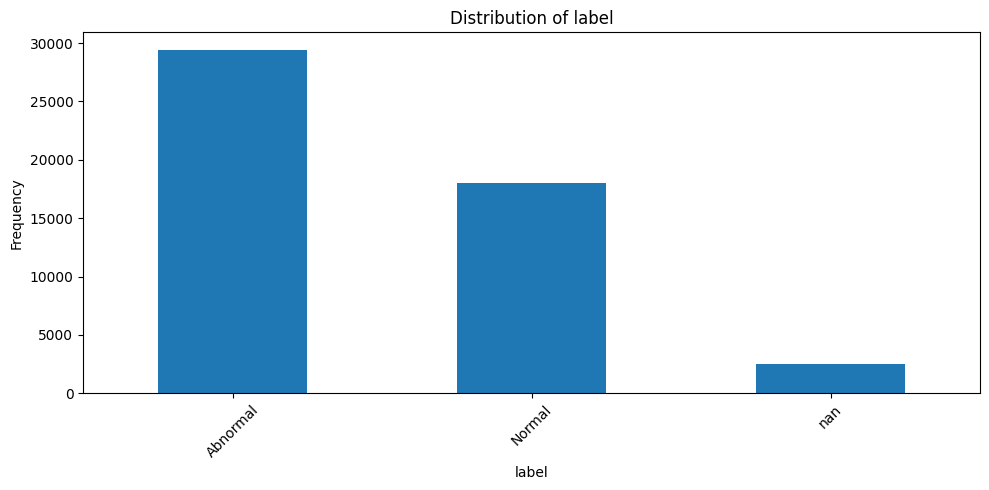

In [15]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

for col in categorical_columns:

    if col == "sublabel":
        continue

    plt.figure(figsize=(10, 5))

    df[col].value_counts(dropna=False).plot(
        kind="bar"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

#Age VS Disease Class

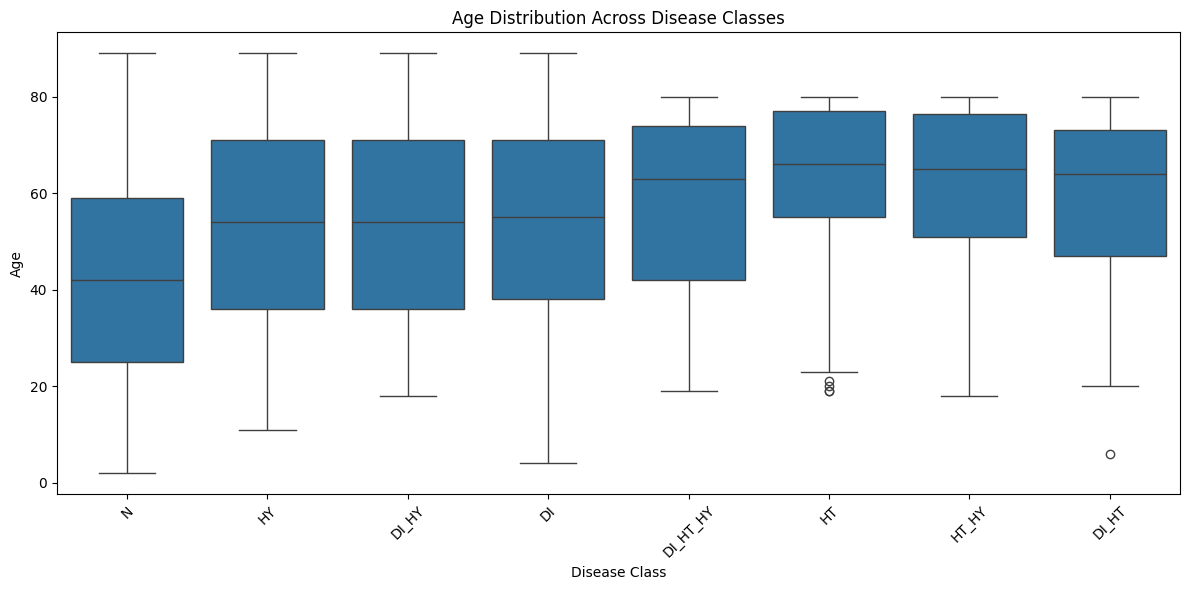

In [16]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="sublabel",
    y="age"
)

plt.title("Age Distribution Across Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#BMI VS Disease Class

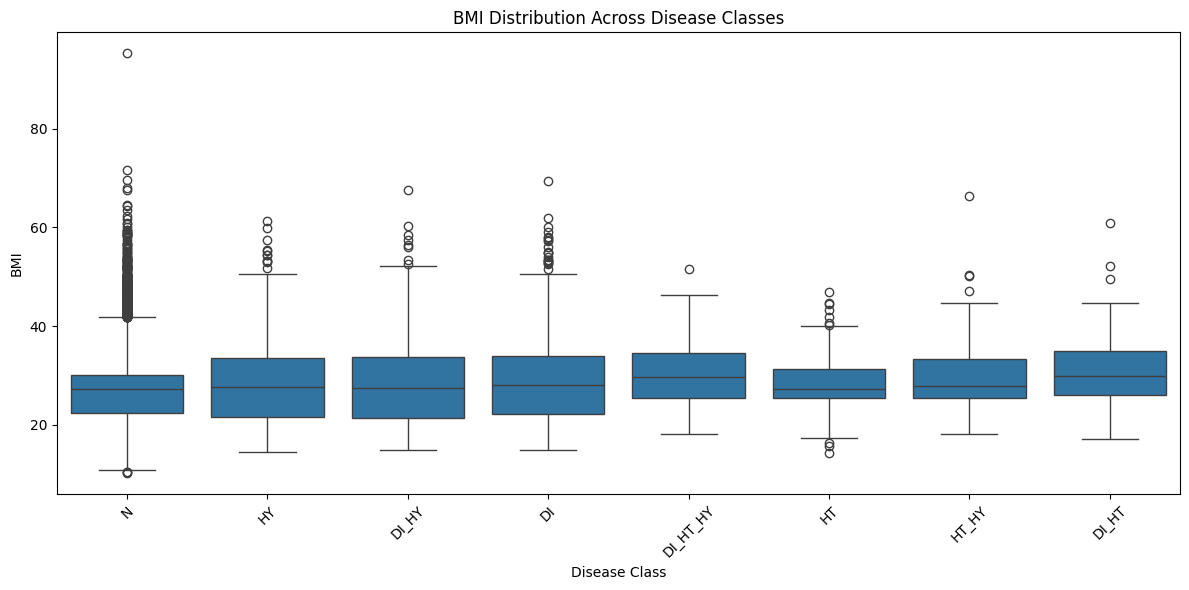

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="sublabel",
    y="bmi"
)

plt.title("BMI Distribution Across Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("BMI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Data Balanced or Imbalanced

In [18]:
# ============================================================
# CLASS DISTRIBUTION - BALANCED OR IMBALANCED?
# ============================================================

# Count each disease class
class_counts = df["sublabel"].value_counts()

print("Class Counts:")
print(class_counts)

Class Counts:
sublabel
N           19020
HY          12422
DI_HY       11828
DI           5679
HT            462
DI_HT         249
HT_HY         190
DI_HT_HY      150
Name: count, dtype: int64


#Data Balance or Imbalance Percentage

In [19]:
class_percentages = (
    df["sublabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nClass Percentages:")
print(class_percentages)


Class Percentages:
sublabel
N           38.04
HY          24.84
DI_HY       23.66
DI          11.36
HT           0.92
DI_HT        0.50
HT_HY        0.38
DI_HT_HY     0.30
Name: proportion, dtype: float64


#**(2) Data Cleaning and Preprocessing**

In [20]:
data = df.copy()

print("Initial shape:", data.shape)

Initial shape: (50000, 37)


#Remove Duplicates

In [21]:
before = len(data)

data = data.drop_duplicates()

after = len(data)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 50000
Rows after removing duplicates: 49994
Duplicates removed: 6


#**Handle Missing Values**

In [22]:
numeric_columns = data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = data.select_dtypes(
    include="object"
).columns.tolist()

# Do not impute the target as a feature.
# Remove rows where target is missing, if any.
if "sublabel" in data.columns:
    data = data.dropna(subset=["sublabel"])

# Numeric columns
for col in numeric_columns:

    if col == "sublabel":
        continue

    data[col] = data[col].fillna(
        data[col].median()
    )

# Categorical columns
for col in categorical_columns:

    if col == "sublabel":
        continue

    mode_value = data[col].mode()[0]

    data[col] = data[col].fillna(
        mode_value
    )

print("Total missing values after imputation:")
print(data.isnull().sum().sum())
print("Data Shape before Imputation: ")
print(df.shape)
print("Data Shape after Imputation: ")
print(data.shape)

Total missing values after imputation:
0
Data Shape before Imputation: 
(50000, 37)
Data Shape after Imputation: 
(49994, 37)


#**Data Transformation**

In [23]:
# Drop rows with missing 'sublabel' to align X and y
data_clean = data.dropna(subset=["sublabel"]).copy()

# Separate features (X) by dropping 'sublabel'
X = data_clean.drop(columns=["sublabel"])

# Define target variable (y)
y = data_clean["sublabel"]

# 1. Print data types of each feature column in X
print("--- X Features Data Types ---")
print(X.dtypes)

# 2. Print data type of the target variable y
print("\n--- Target (y) Data Type ---")
print(y.dtypes)

--- X Features Data Types ---
age_level                object
gender                   object
bmi_level                object
smoking                  object
diabetes                 object
age                     float64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity        object
family_history           object
stress_level             object
low_hdl_cholesterol      object
high_ldl_cholesterol     object
blood_pressure          float64
high_blood_pressure      object
sugar_consumption        object
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl       

In [24]:
# Convert the 'age' column in X from float to integer (using nullable 'Int64' to handle any potential missing values)
# Drop rows with missing 'sublabel' to align X and y
data_clean = data.dropna(subset=["sublabel"]).copy()
data_clean["age"] = pd.to_numeric(data_clean["age"], errors="coerce").astype("Int64")


# Separate features (X) by dropping 'sublabel'
X = data_clean.drop(columns=["sublabel"])

# Define target variable (y)
y = data_clean["sublabel"]

# 1. Print data types of each feature column in X
print("--- X Features Data Types ---")
print(X.dtypes)

# 2. Print data type of the target variable y
print("\n--- Target (y) Data Type ---")
print(y.dtypes)


--- X Features Data Types ---
age_level                object
gender                   object
bmi_level                object
smoking                  object
diabetes                 object
age                       Int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity        object
family_history           object
stress_level             object
low_hdl_cholesterol      object
high_ldl_cholesterol     object
blood_pressure          float64
high_blood_pressure      object
sugar_consumption        object
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl       

#Check Invalid Values

In [25]:
# ============================================================
# CHECK INVALID VALUES
# ============================================================

# Define reasonable ranges for numerical health features
valid_ranges = {
    "age": (1, 90),
    "bmi": (10, 80),
    "HbA1c_level": (0, 20),
    "glucose": (0, 1000),
    "cholesterol": (0, 1000),
    "sleep_hours": (0, 24),
    "triglycerides": (0, 2000),
    "crp_level": (0, 500),
    "homocysteine_level": (0, 100),
    "systolic_bp": (50, 250),
    "diastolic_bp": (30, 200),
    "heart_rate": (20, 250),
    "hdl": (0, 200),
    "ldl": (0, 500)
}


# ------------------------------------------------------------
# Check each column
# ------------------------------------------------------------

print("===== INVALID VALUE CHECK =====\n")

for column, (minimum, maximum) in valid_ranges.items():

    # Check whether column exists
    if column in data.columns:

        invalid = data[
            (data[column] < minimum) |
            (data[column] > maximum)
        ]

        print(f"{column}:")
        print(f"  Valid range   : {minimum} - {maximum}")
        print(f"  Invalid values: {len(invalid)}")

        if len(invalid) > 0:
            print("  Examples:")
            print(invalid[[column]].head())

        print()

===== INVALID VALUE CHECK =====

age:
  Valid range   : 1 - 90
  Invalid values: 0

bmi:
  Valid range   : 10 - 80
  Invalid values: 1
  Examples:
         bmi
46316  95.22

HbA1c_level:
  Valid range   : 0 - 20
  Invalid values: 0

glucose:
  Valid range   : 0 - 1000
  Invalid values: 0

cholesterol:
  Valid range   : 0 - 1000
  Invalid values: 0

sleep_hours:
  Valid range   : 0 - 24
  Invalid values: 0

triglycerides:
  Valid range   : 0 - 2000
  Invalid values: 0

crp_level:
  Valid range   : 0 - 500
  Invalid values: 0

homocysteine_level:
  Valid range   : 0 - 100
  Invalid values: 0

systolic_bp:
  Valid range   : 50 - 250
  Invalid values: 0

diastolic_bp:
  Valid range   : 30 - 200
  Invalid values: 0

heart_rate:
  Valid range   : 20 - 250
  Invalid values: 0

hdl:
  Valid range   : 0 - 200
  Invalid values: 0

ldl:
  Valid range   : 0 - 500
  Invalid values: 0



#Outlier Detection

--- Outlier Detection Summary (IQR Method) ---


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage (%)
17,heart_rate,71.000000,78.000000,7.000000,60.500000,88.500000,12996,26.00
14,diastolic_bp,85.000000,94.000000,9.000000,71.500000,107.500000,11833,23.67
15,alcohol_intake,12.700000,17.200000,4.500000,5.950000,23.950000,11724,23.45
19,ldl,120.000000,139.000000,19.000000,91.500000,167.500000,10933,21.87
18,hdl,59.000000,70.000000,11.000000,42.500000,86.500000,10868,21.74
16,salt_intake,7.400000,9.500000,2.100000,4.250000,12.650000,10487,20.98
13,systolic_bp,127.000000,142.000000,15.000000,104.500000,164.500000,10032,20.07
10,blood_pressure,149.008407,150.654054,1.645647,146.539937,153.122524,5844,11.69
12,homocysteine_level,12.304990,12.657538,0.352548,11.776168,13.186359,5831,11.66
11,crp_level,7.296329,7.755569,0.459240,6.607470,8.444428,5044,10.09


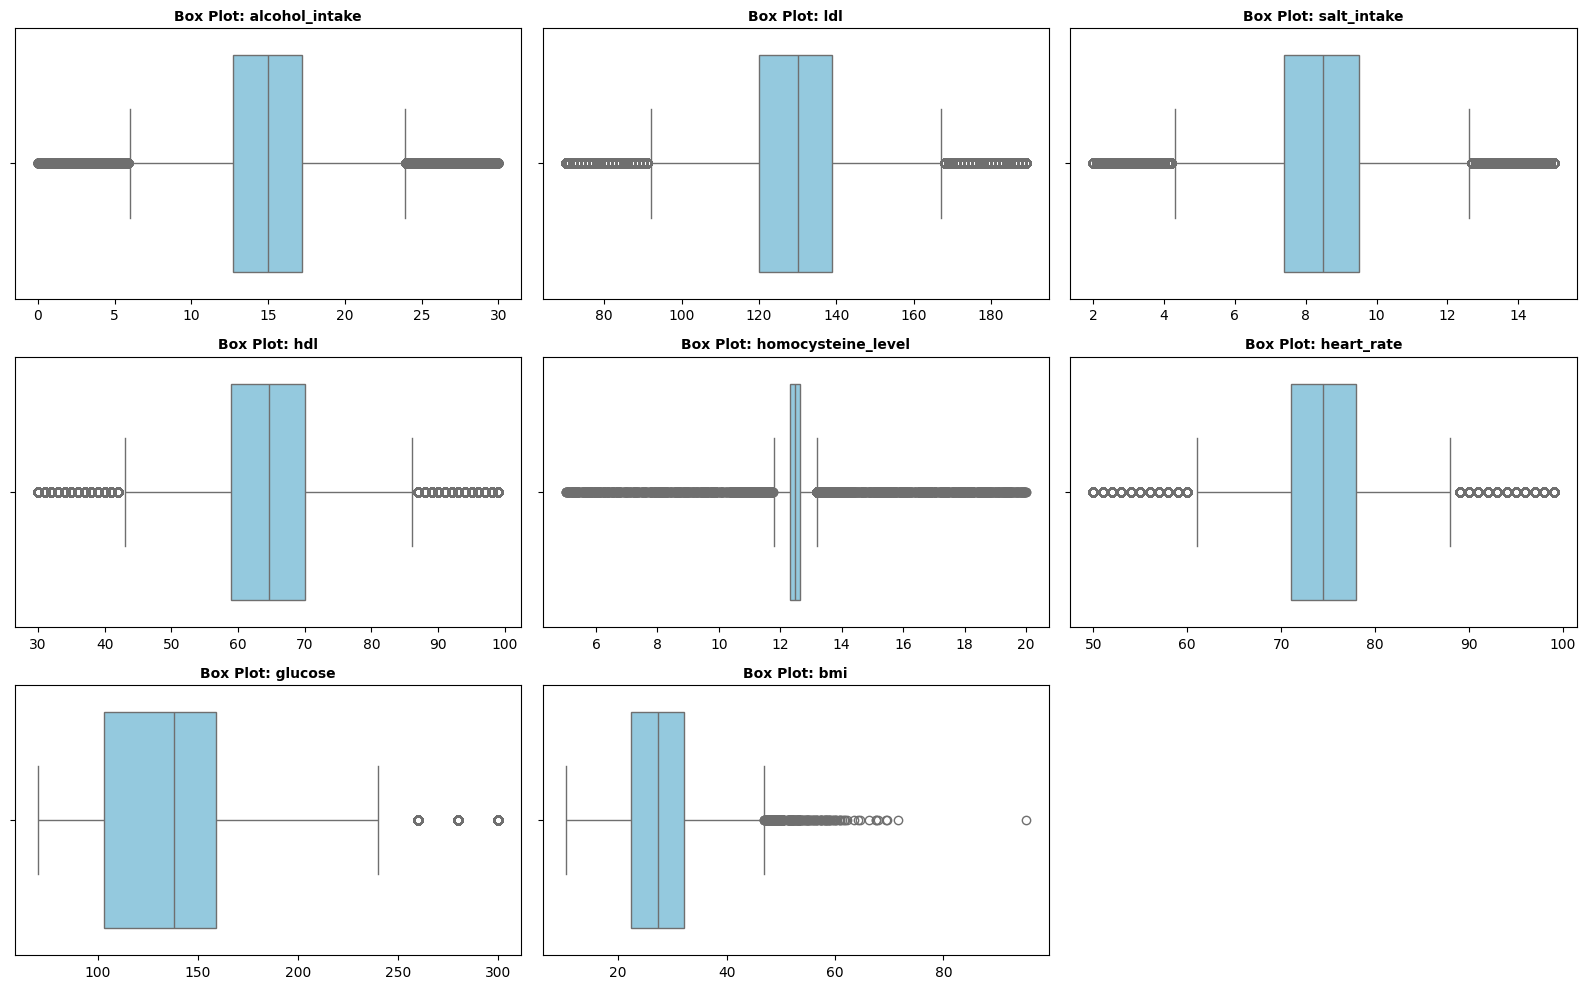


Documented Outlier Treatment Method: IQR Capping (Winsorization at 1.5 * IQR bounds)
Outlier treatment completed successfully! Extreme values have been safely capped.


In [26]:
numerical_cols = data_clean.select_dtypes(include=np.number).columns.tolist()

# 2. Calculate IQR, Lower/Upper bounds, and Outlier statistics
outlier_data = []

for col in numerical_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = data_clean[(data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(X)) * 100

    outlier_data.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": count,
        "Percentage (%)": round(percentage, 2)
    })

# Convert summary into a DataFrame and display
outlier_df = pd.DataFrame(outlier_data)
print("--- Outlier Detection Summary (IQR Method) ---")
display(outlier_df.sort_values(by="Outlier Count", ascending=False))

# 3. Visualization: Box plots for key numerical features
# Selecting top features with notable variations/outliers for clear plotting
key_features = ['alcohol_intake', 'ldl', 'salt_intake', 'hdl', 'homocysteine_level', 'heart_rate', 'glucose', 'bmi']
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_features, 1):
    if col in data.columns:
        plt.subplot(3, 3, i)
        sns.boxplot(x=data[col], color='skyblue')
        plt.title(f'Box Plot: {col}', fontsize=10, fontweight='bold')
        plt.xlabel('')

plt.tight_layout()
plt.show()

# 4. Handling Outliers: Robust Capping (Winsorization) Strategy
# Note: We DO NOT automatically delete outliers because medical datasets frequently contain
# valid extreme physiological measurements (e.g., severe high cholesterol or glucose levels).
# Instead, we apply IQR Capping to limit extreme skews safely without losing data rows.

data_clean = data_clean.copy()
capping_method = "IQR Capping (Winsorization at 1.5 * IQR bounds)"

for col in numerical_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values beyond bounds
    data_clean[col] = np.clip(data_clean[col], lower_bound, upper_bound)

print(f"\nDocumented Outlier Treatment Method: {capping_method}")
print("Outlier treatment completed successfully! Extreme values have been safely capped.")

#**Feature Seleciton**

In [27]:
columns_to_drop_x = [
    "age_level",           # redundant with 'age'
    "age_normalized",      # will be handled in the upcoming normalization step
    "bmi_level",           # redundant with 'bmi'
    "high_ldl_cholesterol",# redundant/derived
    "low_hdl_cholesterol", # redundant/derived
    "high_blood_pressure", # redundant/derived
    "systolic_bp",         # dropping because we are keeping 'blood_pressure'
    "diastolic_bp",        # dropping because we are keeping 'blood_pressure'
    "diabetes",            # target/disease to predict (preventing leakage)
    "hypertension",        # target/disease to predict (preventing leakage)
    "heart_disease",       # target/disease to predict (preventing leakage)
    "disease_flags",       # unwanted metadata column
    "label",               # unwanted/alternative label column
    "sublabel"             # this is our target Y, so drop from X
]

# 2. Define target variable Y
target_column = "sublabel"

# 3. Create X (features) and y (target) safely
existing_cols_to_drop_x = [col for col in columns_to_drop_x if col in df.columns]

X = data_clean.drop(columns=existing_cols_to_drop_x, errors='ignore')
y = data_clean[target_column]

# 4. Assertions to verify cleanup and prevent target leakage
assert target_column not in X.columns, f"Target '{target_column}' found in X!"
assert "age_level" not in X.columns, "'age_level' was not dropped from X!"
assert "diabetes" not in X.columns, "'diabetes' was not dropped from X!"

print(f"Original feature count: {data_clean.shape[1]}")
print(f"Features count in X after selection: {X.shape[1]}")
print(f"Target variable (y) selected: {target_column} (Shape: {y.shape})")

Original feature count: 37
Features count in X after selection: 23
Target variable (y) selected: sublabel (Shape: (49994,))


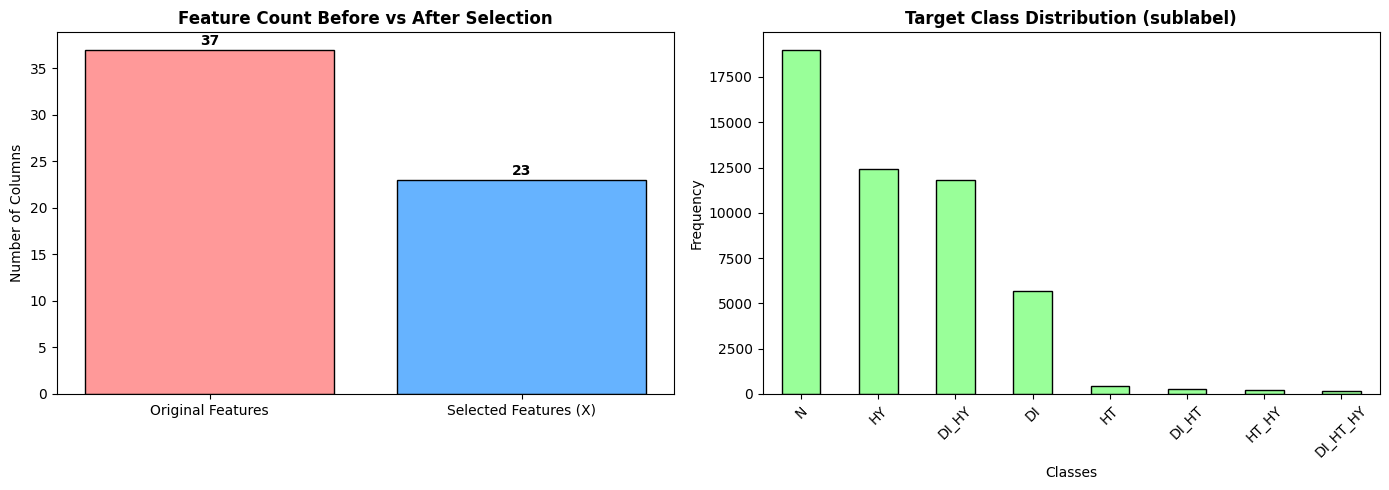

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature count comparison (Before vs After)
categories = ['Original Features', 'Selected Features (X)']
counts = [data_clean.shape[1], X.shape[1]]
axes[0].bar(categories, counts, color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[0].set_title('Feature Count Before vs After Selection', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Columns')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Target class distribution (y)
y.value_counts().plot(kind='bar', ax=axes[1], color='#99ff99', edgecolor='black')
axes[1].set_title('Target Class Distribution (sublabel)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Combined(x+y) Feature Selection Dataset

In [29]:
# 1. X နဲ့ y ကို axis=1 (ဘေးတိုက်) အရ ပေါင်းစပ်ခြင်း
# (X က DataFrame ဖြစ်ပြီး y က Series ဖြစ်နေရင်တောင် pd.concat က အလုပ်လုပ်ပါတယ်)
df_selected = pd.concat([X, y], axis=1)

print("--- Combined Dataset Info ---")
print(f"Shape: {df_selected.shape}")
print(df_selected.head())


--- Combined Dataset Info ---
Shape: (49994, 24)
   gender  smoking  age   bmi  HbA1c_level  glucose  cholesterol  sleep_hours  \
0    Male    Never    6  16.7     6.600000     90.0   228.130653     7.080402   
1  Female   Former   60  26.1     5.389519     91.0   291.500000     5.000000   
2  Female    Never   46  35.9     5.800000    125.0   249.000000     9.300000   
3  Female  Current   51  26.7     7.107000    158.0   247.000000     6.985444   
4  Female    Never   42  21.8     5.396140    193.0   251.000000     4.350000   

   triglycerides physical_activity  ... crp_level homocysteine_level  \
0     156.115578          Moderate  ...  7.824534          11.846610   
1     179.000000              High  ...  7.844901          12.508636   
2     132.000000              High  ...  7.396445          12.637835   
3     100.000000               Low  ...  7.897769          12.488407   
4     245.000000              High  ...  7.682855          12.313133   

   alcohol_intake salt_intake  

#**Encoding**

#Target Class Encoding

In [30]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target classes:")
for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)

Target classes:
0 = DI
1 = DI_HT
2 = DI_HT_HY
3 = DI_HY
4 = HT
5 = HT_HY
6 = HY
7 = N


#Categorical Features Encoding

In [31]:
# 1. Automatically identify categorical and numerical features from X
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns before encoding:")
for col in categorical_features:
    print(f"  - {col}: {X[col].nunique()} categories")

# Imputation of Missing Values in X before OneHotEncoder
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())
X[categorical_features] = X[categorical_features].fillna(X[categorical_features].mode().iloc[0])

# 2. Configure One-Hot Encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# 3. Build ColumnTransformer to process categorical features and pass numerical features through
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_features)
    ],
    remainder='passthrough'
)

# 4. Fit and transform the feature matrix
X_encoded_array = preprocessor.fit_transform(X)

print(f"\nNumber of features after encoding: {X_encoded_array.shape[1]}")
print("Categorical columns after encoding:")
for col in preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features):
    print(f"  - {col}")

Categorical columns before encoding:
  - gender: 2 categories
  - smoking: 3 categories
  - physical_activity: 3 categories
  - family_history: 2 categories
  - stress_level: 3 categories
  - sugar_consumption: 3 categories
  - education_level: 3 categories
  - employment_status: 3 categories

Number of features after encoding: 37
Categorical columns after encoding:
  - gender_Female
  - gender_Male
  - smoking_Current
  - smoking_Former
  - smoking_Never
  - physical_activity_High
  - physical_activity_Low
  - physical_activity_Moderate
  - family_history_No
  - family_history_Yes
  - stress_level_High
  - stress_level_Low
  - stress_level_Medium
  - sugar_consumption_High
  - sugar_consumption_Low
  - sugar_consumption_Medium
  - education_level_Primary
  - education_level_Secondary
  - education_level_Tertiary
  - employment_status_Employed
  - employment_status_Retired
  - employment_status_Unemployed


#Correlation Analysis

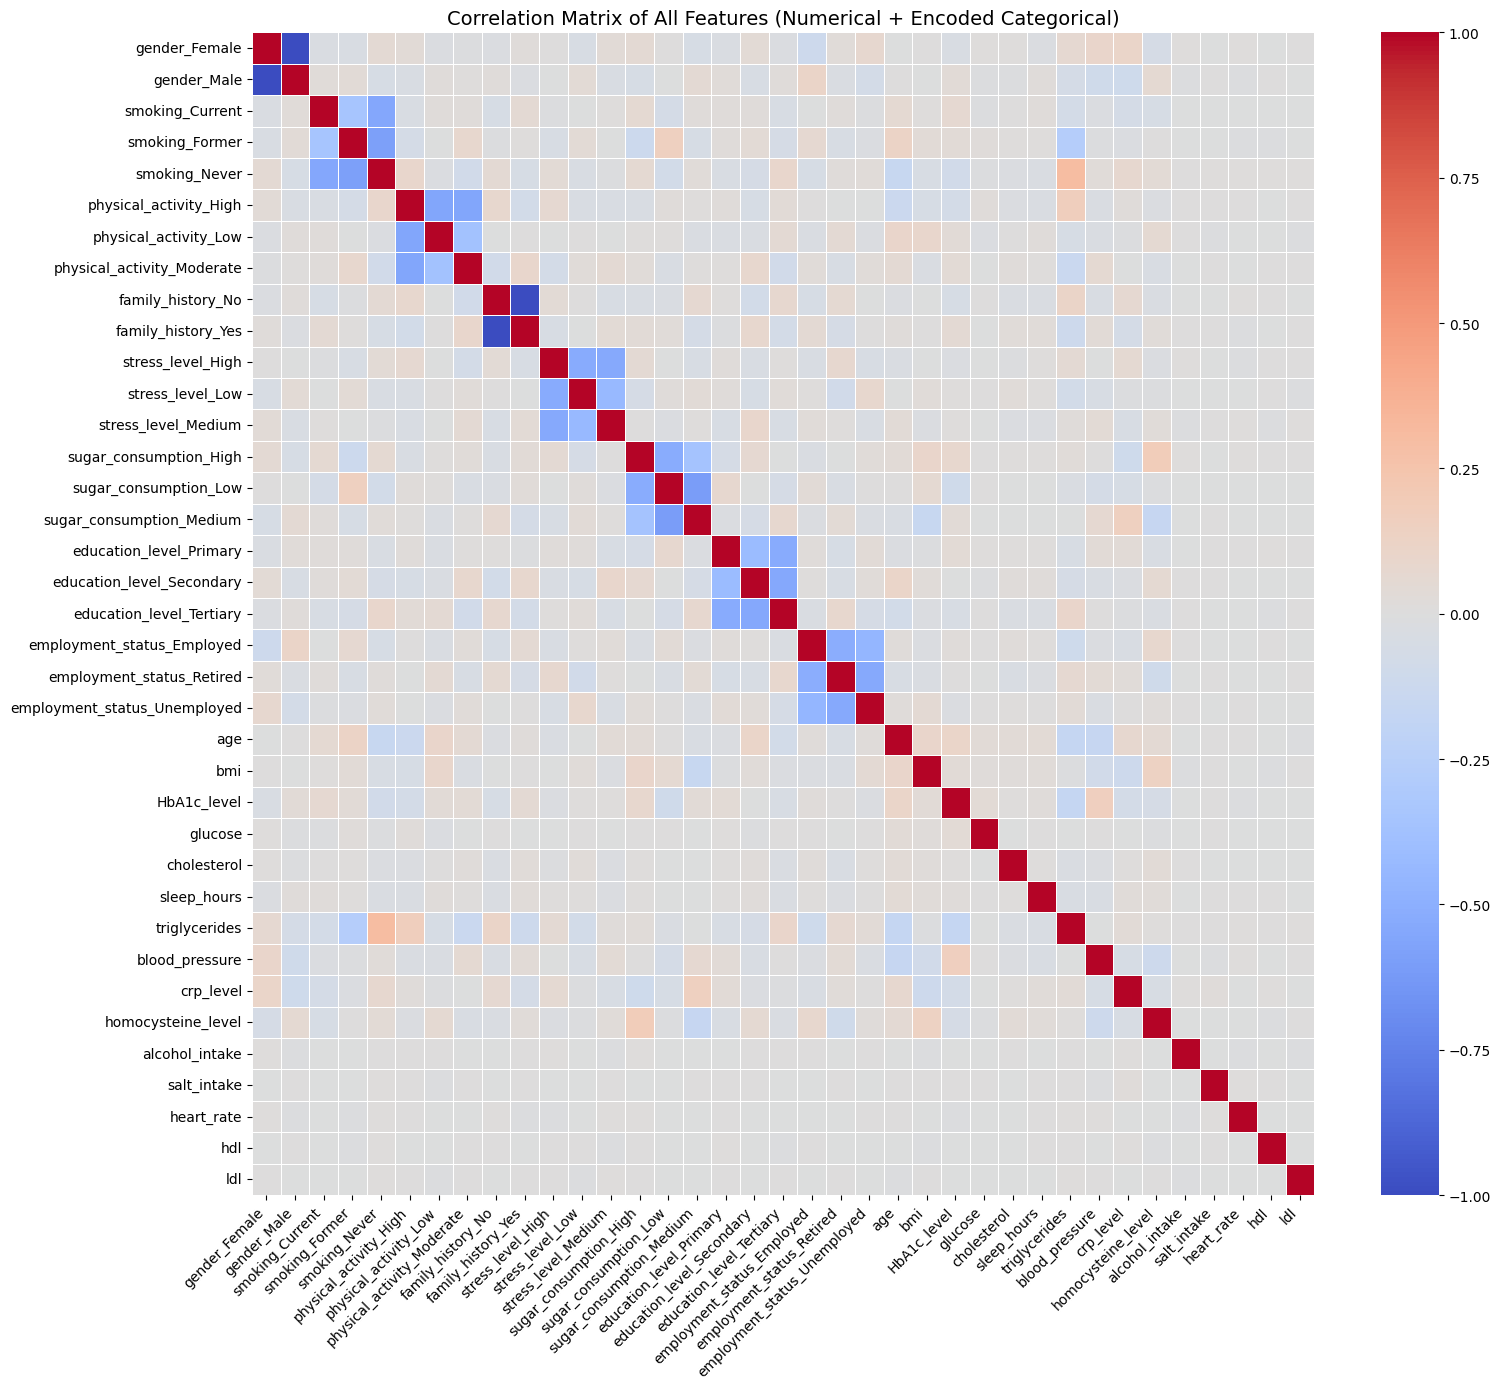

In [32]:
# 1. One-Hot Encoder လုပ်ထားသော Categorical column နာမည်များကို ထုတ်ယူခြင်း
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# 2. Numerical column နာမည်များကို ရယူခြင်း
numerical_features = X.select_dtypes(include=['float64', 'int64', 'Int64']).columns.tolist()

# 3. Column နာမည်အားလုံးကို ပေါင်းစပ်ခြင်း
all_feature_names = list(encoded_cat_names) + numerical_features

# 4. Encoded Array ကို DataFrame အဖြစ်သို့ ပြောင်းလဲခြင်း
X_final_corr = pd.DataFrame(X_encoded_array, columns=all_feature_names, index=X.index)

# 5. Correlation Matrix တွက်ချက်ခြင်း (Features အားလုံးပါဝင်မည်)
correlation_matrix = X_final_corr.corr(method='pearson')

# 6. Heatmap ဖြင့် ေဖာ်ပြခြင်း
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Features အရမ်းများနေပါက True အစား False ထားခြင်းက ပိုရှင်းပါတယ်
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix of All Features (Numerical + Encoded Categorical)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#**Data Normalization**

In [33]:
# 1. Finding Numerical columns
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# 2. Initialize MinMaxScaler
scaler = MinMaxScaler()

# 3. Normalize numerical columns into [0,1] range
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("--- Numerical Features Normalized to [0, 1] Range Successfully ---")
print(X[numerical_features].head())

--- Numerical Features Normalized to [0, 1] Range Successfully ---
        age       bmi  HbA1c_level   glucose  cholesterol  sleep_hours  \
0  0.045977  0.174863     0.563636  0.115607     0.547362     0.525077   
1  0.666667  0.431694     0.343549  0.121387     1.000000     0.125000   
2  0.505747  0.699454     0.418182  0.317919     0.696429     0.951923   
3  0.563218  0.448087     0.655818  0.508671     0.682143     0.506816   
4  0.459770  0.314208     0.344753  0.710983     0.710714     0.000000   

   triglycerides  blood_pressure  crp_level  homocysteine_level  \
0       0.303187        0.566539   0.662543            0.049952   
1       0.368571        0.412387   0.673630            0.519410   
2       0.234286        0.625000   0.429501            0.611028   
3       0.142857        0.000000   0.702411            0.505066   
4       0.557143        0.537632   0.585416            0.380774   

   alcohol_intake  salt_intake  heart_rate       hdl       ldl  
0        0.501823   

#Verification of Normalized Numerical Features

In [34]:
# Seleciton of Numerical features
numerical_features = X.select_dtypes(include=['float64', 'int64', 'Int64']).columns.tolist()

# Verification of Min and Max values
verification_df = pd.DataFrame({
    'Min Value': X[numerical_features].min(),
    'Max Value': X[numerical_features].max()
})

print("--- Min-Max Range Verification ---")
print(verification_df)

--- Min-Max Range Verification ---
                    Min Value  Max Value
age                       0.0        1.0
bmi                       0.0        1.0
HbA1c_level               0.0        1.0
glucose                   0.0        1.0
cholesterol               0.0        1.0
sleep_hours               0.0        1.0
triglycerides             0.0        1.0
blood_pressure            0.0        1.0
crp_level                 0.0        1.0
homocysteine_level        0.0        1.0
alcohol_intake            0.0        1.0
salt_intake               0.0        1.0
heart_rate                0.0        1.0
hdl                       0.0        1.0
ldl                       0.0        1.0


#**(3) Descriptive Mining**

In [35]:
# DESCRIPTIVE Data Statistics

descriptive_df = df_selected.copy()

# DESCRIPTIVE ASSOCIATION MINING

# Your 23 descriptive input features
descriptive_features = [
    'gender',
    'smoking',
    'age',
    'bmi',
    'HbA1c_level',
    'glucose',
    'cholesterol',
    'sleep_hours',
    'triglycerides',
    'physical_activity',
    'family_history',
    'stress_level',
    'blood_pressure',
    'sugar_consumption',
    'crp_level',
    'homocysteine_level',
    'alcohol_intake',
    'salt_intake',
    'heart_rate',
    'hdl',
    'ldl',
    'education_level',
    'employment_status'
]

# Target variable
TARGET = 'sublabel'

# Create descriptive mining dataset
# descriptive_df = df[
#     descriptive_features + [TARGET]
# ].copy()

print("Descriptive mining dataset shape:",
      descriptive_df.shape)

print("\nInput features:")
print(descriptive_features)

print("Target:")
print(TARGET)

print("Descriptive mining dataset shape:",
      descriptive_df.shape)

Descriptive mining dataset shape: (49994, 24)

Input features:
['gender', 'smoking', 'age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status']
Target:
sublabel
Descriptive mining dataset shape: (49994, 24)


#Clustering

In [36]:
# ============================================
# 7.0 PREPARE FEATURES FOR K-MEANS
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt

# Copy dataset
clustering_df = descriptive_df.copy()

# Remove target-related columns
exclude_cols = ['sublabel', 'label', 'disease_flags']

feature_df = clustering_df.drop(
    columns=[c for c in exclude_cols if c in clustering_df.columns],
    errors='ignore'
)

# Use numerical features only
X = feature_df.select_dtypes(include=np.number).copy()

# Remove missing values
X = X.dropna()

print("Clustering features:")
print(X.columns.tolist())
print("\nNumber of observations:", len(X))

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed.")

Clustering features:
['age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']

Number of observations: 49994
Scaling completed.


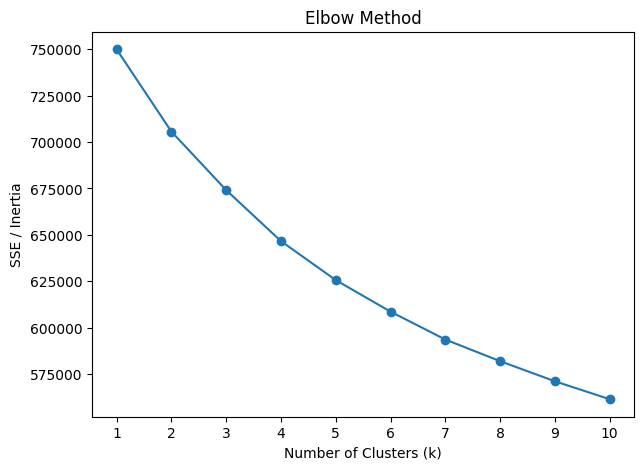

In [37]:
# ============================================
# 7.1 ELBOW METHOD
# ============================================

inertias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

,K,Calinski-Harabasz Score
0,2,3139.099250
1,3,2811.138325
2,4,2661.760283
3,5,2482.219625
4,6,2320.252788
5,7,2193.033584
6,8,2060.089795
7,9,1955.280201
8,10,1863.209581


Best K by Calinski-Harabasz Index: 2


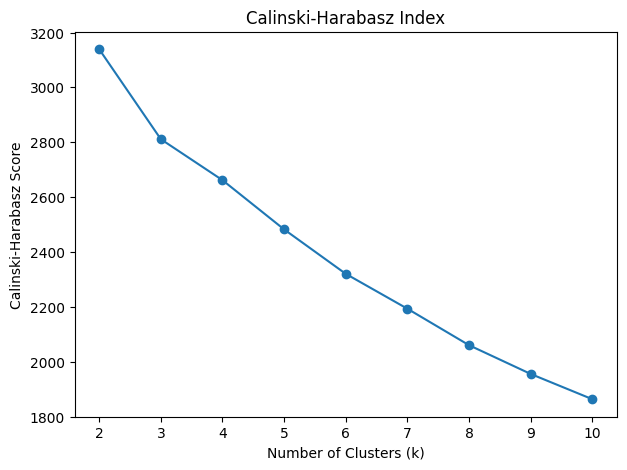

In [38]:
# ============================================
# 7.2 CALINSKI-HARABASZ INDEX
# ============================================

ch_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = calinski_harabasz_score(
        X_scaled,
        cluster_labels
    )

    ch_scores.append(score)

ch_results = pd.DataFrame({
    'K': range(2, 11),
    'Calinski-Harabasz Score': ch_scores
})

display(ch_results)

best_k_ch = ch_results.loc[
    ch_results['Calinski-Harabasz Score'].idxmax(),
    'K'
]

print("Best K by Calinski-Harabasz Index:", best_k_ch)

plt.figure(figsize=(7, 5))
plt.plot(
    ch_results['K'],
    ch_results['Calinski-Harabasz Score'],
    marker='o'
)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Index')
plt.xticks(range(2, 11))
plt.show()

In [39]:
# ============================================
# 7.3 FINAL K-MEANS
# ============================================

final_k = int(best_k_ch)

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

clustering_result = X.copy()
clustering_result['Cluster'] = cluster_labels

print("Final K:", final_k)
print("Inertia:", round(final_kmeans.inertia_, 4))

print("\nCluster Sizes:")
print(clustering_result['Cluster'].value_counts().sort_index())

print(
    "\nCalinski-Harabasz Score:",
    round(
        calinski_harabasz_score(X_scaled, cluster_labels),
        4
    )
)

Final K: 2
Inertia: 705605.1227

Cluster Sizes:
Cluster
0    23377
1    26617
Name: count, dtype: int64

Calinski-Harabasz Score: 3139.0992


In [40]:
# Cluster centers in original scale

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=X.columns
)

cluster_centers.index = [
    f"Cluster {i}"
    for i in range(final_k)
]

display(cluster_centers)

,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,alcohol_intake,salt_intake,heart_rate,hdl,ldl
Cluster 0,40.047821,25.919885,5.475363,131.387812,222.019705,6.808728,221.539632,149.560390,7.599751,12.488010,15.302372,8.469118,74.564710,64.948296,130.417454
Cluster 1,58.074566,28.760005,6.340175,138.631815,225.377046,7.085933,142.132553,149.919137,7.417174,12.467701,14.703859,8.451553,74.324214,64.105635,129.090507


Average Silhouette Score: 0.063


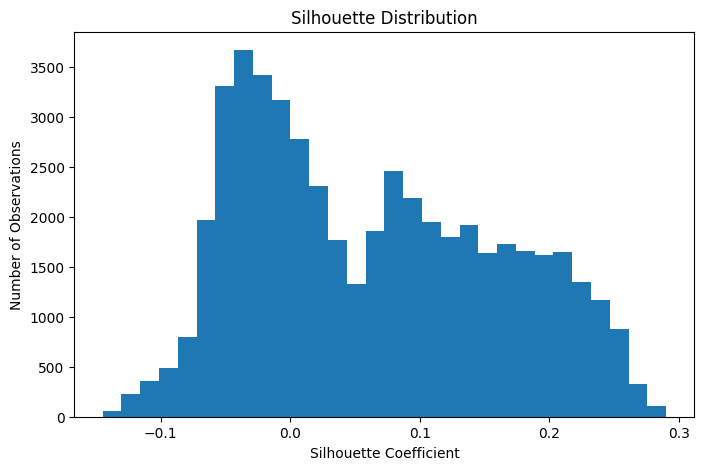

In [41]:
# ============================================
# 7.4 SILHOUETTE COEFFICIENT
# ============================================

sil_samples = silhouette_samples(
    X_scaled,
    cluster_labels
)

sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Average Silhouette Score:",
    round(sil_score, 4)
)

# Add individual silhouette values
clustering_result['Silhouette'] = sil_samples

plt.figure(figsize=(8, 5))
plt.hist(sil_samples, bins=30)
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Number of Observations')
plt.title('Silhouette Distribution')
plt.show()

In [42]:
# ============================================
# 7.5 CLUSTER PROFILE
# ============================================

profile_df = descriptive_df.loc[X.index].copy()
profile_df['Cluster'] = cluster_labels

# Numerical feature means
numeric_profile = profile_df.groupby('Cluster')[X.columns].mean()

display(numeric_profile)

,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,alcohol_intake,salt_intake,heart_rate,hdl,ldl
Cluster,,,,,,,,,,,,,,,
0,40.029388,25.906806,5.474767,131.379681,222.023434,6.810372,221.524922,149.559656,7.600082,12.487873,15.284810,8.474825,74.570989,64.929473,130.471411
1,58.075178,28.769038,6.339952,138.632697,225.370870,7.084249,142.214088,149.919471,7.417042,12.467839,14.719801,8.446557,74.318906,64.122896,129.044265


In [41]:
# Target is ONLY used for interpretation

cluster_sublabel = pd.crosstab(
    profile_df['Cluster'],
    profile_df['sublabel'],
    normalize='index'
) * 100

display(cluster_sublabel.round(2))

sublabel,DI,DI_HT,DI_HT_HY,DI_HY,HT,HT_HY,HY,N
Cluster,,,,,,,,
0,3.8,0.34,0.24,6.17,1.13,0.53,25.48,62.30
1,18.0,0.64,0.35,39.02,0.74,0.25,24.29,16.71


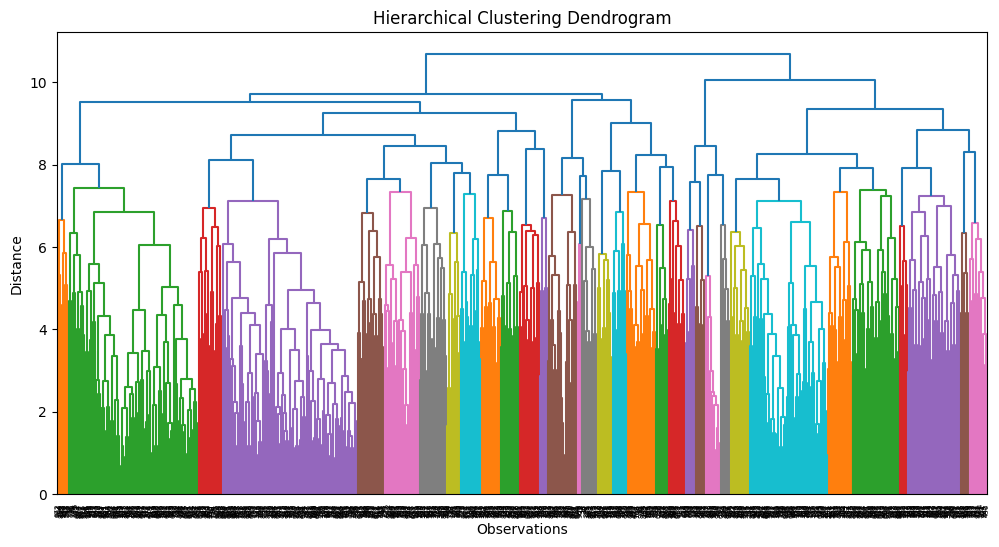

In [43]:
# ============================================
# PART 8 - HIERARCHICAL CLUSTERING
# ============================================

from scipy.cluster.hierarchy import linkage, dendrogram

sample_size = min(1000, len(X_scaled))

sample_indices = np.random.RandomState(42).choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

# Complete linkage
Z = linkage(
    X_sample,
    method='complete'
)

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

#Finding Frequent Pattern and Association Rule

In [44]:
association_df = descriptive_df.copy()

# Identify and bin numerical features
numerical_cols = association_df[descriptive_features].select_dtypes(include='number').columns
print("Numerical features:", list(numerical_cols))
from mlxtend.preprocessing import TransactionEncoder

# Convert each row into a transaction
transactions = association_df.astype(str).values.tolist()

# Sparse encoding (RAM saving)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions, sparse=True)

transaction_df = pd.DataFrame.sparse.from_spmatrix(
    te_array,
    columns=te.columns_
)

print("Transaction matrix shape:", transaction_df.shape)

for col in numerical_cols:
    association_df[col] = pd.qcut(association_df[col], 3, labels=['Low', 'Medium', 'High'], duplicates='drop')

# Format all descriptive features and target into 'col=value' strings
for col in list(descriptive_features) + [target_column]:
    association_df[col] = col + "=" + association_df[col].astype(str)

display(association_df.head(10))


Numerical features: ['age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']
Transaction matrix shape: (49994, 8753)


,gender,smoking,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,...,crp_level,homocysteine_level,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,sublabel
0,gender=Male,smoking=Never,age=Low,bmi=Low,HbA1c_level=High,glucose=Low,cholesterol=Medium,sleep_hours=Medium,triglycerides=Medium,physical_activity=Moderate,...,crp_level=High,homocysteine_level=Low,alcohol_intake=Medium,salt_intake=Medium,heart_rate=Medium,hdl=High,ldl=Medium,education_level=Tertiary,employment_status=Employed,sublabel=N
1,gender=Female,smoking=Former,age=Medium,bmi=Medium,HbA1c_level=Low,glucose=Low,cholesterol=High,sleep_hours=Low,triglycerides=Medium,physical_activity=High,...,crp_level=High,homocysteine_level=Medium,alcohol_intake=Low,salt_intake=Low,heart_rate=High,hdl=High,ldl=Medium,education_level=Primary,employment_status=Employed,sublabel=N
2,gender=Female,smoking=Never,age=Medium,bmi=High,HbA1c_level=Medium,glucose=Medium,cholesterol=High,sleep_hours=High,triglycerides=Low,physical_activity=High,...,crp_level=Medium,homocysteine_level=High,alcohol_intake=Low,salt_intake=Low,heart_rate=Low,hdl=High,ldl=Low,education_level=Secondary,employment_status=Unemployed,sublabel=HY
3,gender=Female,smoking=Current,age=Medium,bmi=Medium,HbA1c_level=High,glucose=High,cholesterol=High,sleep_hours=Medium,triglycerides=Low,physical_activity=Low,...,crp_level=High,homocysteine_level=Medium,alcohol_intake=High,salt_intake=High,heart_rate=Low,hdl=High,ldl=High,education_level=Primary,employment_status=Retired,sublabel=DI_HY
4,gender=Female,smoking=Never,age=Medium,bmi=Low,HbA1c_level=Low,glucose=High,cholesterol=High,sleep_hours=Low,triglycerides=High,physical_activity=High,...,crp_level=High,homocysteine_level=Low,alcohol_intake=Medium,salt_intake=Low,heart_rate=Low,hdl=Low,ldl=High,education_level=Tertiary,employment_status=Unemployed,sublabel=N
5,gender=Male,smoking=Former,age=Medium,bmi=Low,HbA1c_level=High,glucose=Medium,cholesterol=Low,sleep_hours=Medium,triglycerides=Low,physical_activity=Low,...,crp_level=Medium,homocysteine_level=High,alcohol_intake=Medium,salt_intake=High,heart_rate=Low,hdl=Low,ldl=High,education_level=Primary,employment_status=Retired,sublabel=DI_HY
6,gender=Female,smoking=Never,age=High,bmi=Low,HbA1c_level=Low,glucose=Medium,cholesterol=High,sleep_hours=High,triglycerides=Medium,physical_activity=Moderate,...,crp_level=Low,homocysteine_level=Low,alcohol_intake=Medium,salt_intake=Medium,heart_rate=Medium,hdl=Medium,ldl=Medium,education_level=Tertiary,employment_status=Retired,sublabel=N
7,gender=Female,smoking=Never,age=High,bmi=High,HbA1c_level=Medium,glucose=High,cholesterol=Low,sleep_hours=Low,triglycerides=Medium,physical_activity=High,...,crp_level=High,homocysteine_level=High,alcohol_intake=Medium,salt_intake=High,heart_rate=High,hdl=Low,ldl=High,education_level=Tertiary,employment_status=Retired,sublabel=N
8,gender=Male,smoking=Current,age=Low,bmi=Low,HbA1c_level=Medium,glucose=High,cholesterol=Low,sleep_hours=High,triglycerides=Low,physical_activity=Moderate,...,crp_level=High,homocysteine_level=High,alcohol_intake=Low,salt_intake=Low,heart_rate=Low,hdl=Low,ldl=Low,education_level=Tertiary,employment_status=Retired,sublabel=HY
9,gender=Female,smoking=Former,age=Medium,bmi=High,HbA1c_level=Low,glucose=High,cholesterol=Medium,sleep_hours=Medium,triglycerides=Medium,physical_activity=Low,...,crp_level=Medium,homocysteine_level=Medium,alcohol_intake=Medium,salt_intake=High,heart_rate=Medium,hdl=Medium,ldl=Medium,education_level=Primary,employment_status=Unemployed,sublabel=HY


In [45]:
from mlxtend.preprocessing import TransactionEncoder

# Convert each row into a transaction
transactions = association_df.astype(str).values.tolist()

# Sparse encoding (RAM saving)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions, sparse=True)

transaction_df = pd.DataFrame.sparse.from_spmatrix(
    te_array,
    columns=te.columns_
)
print("Before Transaction", association_df.shape)
print("Transaction matrix shape:", transaction_df.shape)

Before Transaction (49994, 24)
Transaction matrix shape: (49994, 75)


In [45]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(
    transaction_df,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)

print("Number of frequent itemsets:", len(frequent_itemsets))

display(frequent_itemsets.sort_values(
    'support',
    ascending=False
).head(20))

Number of frequent itemsets: 13844


,support,itemsets
65,0.581950,(family_history=No)
24,0.550306,(gender=Female)
0,0.484898,(smoking=Never)
51,0.462636,(sugar_consumption=Low)
25,0.457615,(physical_activity=High)
1,0.449694,(gender=Male)
2,0.418050,(family_history=Yes)
3,0.407509,(education_level=Tertiary)
69,0.394247,(stress_level=High)
4,0.380326,(sublabel=N)


In [46]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)
# Keep useful positive associations
rules = rules[rules['lift'] >=1].copy()

rules = rules.sort_values(
    ['lift', 'confidence', 'support'],
    ascending=False
)
print("Number of association rules:", len(rules))

display(
    rules[
        ['antecedents', 'consequents',
         'support', 'confidence', 'lift']
    ].head(20)
)

Number of association rules: 29552


,antecedents,consequents,support,confidence,lift
19365,"(crp_level=Medium, homocysteine_level=Medium)",(smoking=Former),0.105033,0.807722,2.974897
19366,(smoking=Former),"(crp_level=Medium, homocysteine_level=Medium)",0.105033,0.386842,2.974897
31676,(sublabel=DI_HY),"(HbA1c_level=High, ldl=Low)",0.094551,0.399645,2.959101
31675,"(HbA1c_level=High, ldl=Low)",(sublabel=DI_HY),0.094551,0.700089,2.959101
31444,"(HbA1c_level=High, ldl=High)",(sublabel=DI_HY),0.090751,0.698537,2.952543
31445,(sublabel=DI_HY),"(HbA1c_level=High, ldl=High)",0.090751,0.383581,2.952543
31348,"(HbA1c_level=High, heart_rate=Low)",(sublabel=DI_HY),0.097272,0.697504,2.948176
31349,(sublabel=DI_HY),"(HbA1c_level=High, heart_rate=Low)",0.097272,0.411143,2.948176
31520,"(hdl=Low, HbA1c_level=High)",(sublabel=DI_HY),0.095671,0.697129,2.946589
31522,(sublabel=DI_HY),"(hdl=Low, HbA1c_level=High)",0.095671,0.404379,2.946589


In [47]:
# ============================================
# CHECK RULES FOR EACH OF 8 DISEASE CLASSES
# ============================================

disease_classes = [
    'N',
    'DI',
    'HY',
    'HT',
    'DI_HY',
    'DI_HT',
    'HY_HT',
    'DI_HY_HT'
]

print("Number of rules for each disease class:\n")

for disease_class in disease_classes:

    # IMPORTANT: use "sublabel" (lowercase l)
    target = f"sublabel={disease_class}"

    class_rules = rules[
        rules['consequents'].apply(
            lambda x: target in x
        )
    ]

    print(f"{disease_class:10s}: {len(class_rules)} rules")

Number of rules for each disease class:

N         : 823 rules
DI        : 0 rules
HY        : 150 rules
HT        : 0 rules
DI_HY     : 149 rules
DI_HT     : 0 rules
HY_HT     : 0 rules
DI_HY_HT  : 0 rules


In [48]:
# ============================================
# BEST RULE FOR EACH OF 8 DISEASE CLASSES
# ============================================

disease_classes = [
    'N',
    'DI',
    'HY',
    'HT',
    'DI_HY',
    'DI_HT',
    'HY_HT',
    'DI_HY_HT'
]

best_rules = []

for disease_class in disease_classes:

    target = f"sublabel={disease_class}"

    # Find rules where disease class is the consequent
    class_rules = rules[
        rules['consequents'].apply(
            lambda x: target in x
        )
    ].copy()

    if class_rules.empty:
        print(f"⚠️ No rule found for {disease_class}")
        continue

    # Best rule:
    # 1. Highest Lift
    # 2. Highest Confidence
    # 3. Highest Support
    best = class_rules.sort_values(
        ['lift', 'confidence', 'support'],
        ascending=False
    ).iloc[0]

    best_rules.append({
        'Disease Class': disease_class,
        'Antecedent': ' AND '.join(sorted(best['antecedents'])),
        'Consequent': target,
        'Support': round(best['support'], 4),
        'Confidence': round(best['confidence'], 4),
        'Lift': round(best['lift'], 4)
    })

best_rules_df = pd.DataFrame(best_rules)

print(
    "Number of disease classes with best rules:",
    len(best_rules_df)
)

display(best_rules_df)

⚠️ No rule found for DI
⚠️ No rule found for HT
⚠️ No rule found for DI_HT
⚠️ No rule found for HY_HT
⚠️ No rule found for DI_HY_HT
Number of disease classes with best rules: 3


,Disease Class,Antecedent,Consequent,Support,Confidence,Lift
0,N,heart_rate=Medium,sublabel=N,0.1921,0.5880,2.5846
1,HY,HbA1c_level=Low AND sleep_hours=High,sublabel=HY,0.0692,0.6598,2.6555
2,DI_HY,HbA1c_level=High AND ldl=Low,sublabel=DI_HY,0.0946,0.7001,2.9591


#**(4) Predictive Mining**

#Sampling

In [46]:
# ============================================================
# 4.1 TRAIN-TEST SPLIT BEFORE SAMPLING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import time

TARGET = "sublabel"

# Use the feature-selection definition already established above
drop_cols = [c for c in columns_to_drop_x if c in data_clean.columns and c != TARGET]

X_model = data_clean.drop(columns=drop_cols, errors="ignore").drop(columns=[TARGET], errors="ignore").copy()
y_model = data_clean[TARGET].copy()

# Ensure the target is aligned
X_model, y_model = X_model.align(y_model, join="inner", axis=0)

# Identify feature types from the RAW selected features
categorical_features_model = X_model.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features_model = X_model.select_dtypes(
    include=np.number
).columns.tolist()

print("Selected feature count:", X_model.shape[1])
print("Categorical features:", categorical_features_model)
print("Numerical features:", numerical_features_model)

# ------------------------------------------------------------
# STRATIFIED 80/20 SPLIT - BEFORE ANY SAMPLING
# ------------------------------------------------------------

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("\n========== STRATIFIED TRAIN-TEST SPLIT ==========")
print("Training data:", X_train_raw.shape)
print("Testing data :", X_test_raw.shape)

print("\nTraining class distribution BEFORE sampling:")
display(
    y_train_raw.value_counts()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

print("\nTesting class distribution:")
display(
    y_test_raw.value_counts()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

Selected feature count: 23
Categorical features: ['gender', 'smoking', 'physical_activity', 'family_history', 'stress_level', 'sugar_consumption', 'education_level', 'employment_status']
Numerical features: ['age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']

========== STRATIFIED TRAIN-TEST SPLIT ==========
Training data: (39995, 23)
Testing data : (9999, 23)

Training class distribution BEFORE sampling:


,Sublabel,Count
0,N,15211
1,HY,9938
2,DI_HY,9462
3,DI,4543
4,HT,370
5,DI_HT,199
6,HT_HY,152
7,DI_HT_HY,120



Testing class distribution:


,Sublabel,Count
0,N,3803
1,HY,2484
2,DI_HY,2366
3,DI,1136
4,HT,92
5,DI_HT,50
6,HT_HY,38
7,DI_HT_HY,30


In [47]:
# ============================================================
# 4.2 RANDOM OVER-SAMPLING
# ============================================================

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_raw,
    y_train_raw
)

print("========== RANDOM OVER-SAMPLING ==========")
print("Before sampling:", X_train_raw.shape)
print("After ROS      :", X_train_ros.shape)

ros_dist = (
    pd.Series(y_train_ros)
    .value_counts()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

ros_dist["Percentage"] = (
    ros_dist["Count"] / len(y_train_ros) * 100
).round(2)

display(ros_dist)

========== RANDOM OVER-SAMPLING ==========
Before sampling: (39995, 23)
After ROS      : (121688, 23)


,Sublabel,Count,Percentage
0,HY,15211,12.5
1,N,15211,12.5
2,DI_HY,15211,12.5
3,DI,15211,12.5
4,HT,15211,12.5
5,HT_HY,15211,12.5
6,DI_HT_HY,15211,12.5
7,DI_HT,15211,12.5


In [48]:
# ============================================================
# 4.3 SMOTE SAMPLING
# ============================================================

from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# Encode the training data first
# ------------------------------------------------------------

# Use the SAME preprocessor from your original notebook
X_train_encoded = preprocessor.transform(X_train_raw)

X_test_encoded = preprocessor.transform(X_test_raw)

# Convert to numpy arrays
X_train_encoded = np.asarray(
    X_train_encoded,
    dtype=np.float64
)

X_test_encoded = np.asarray(
    X_test_encoded,
    dtype=np.float64
)

print("Before SMOTE:", X_train_encoded.shape)


# ------------------------------------------------------------
# Apply SMOTE ONLY to training data
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train_raw
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("After SMOTE :", X_train_smote.shape)

print("\nClass distribution BEFORE SMOTE:")

display(
    pd.Series(y_train_raw)
    .value_counts()
    .sort_index()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

print("\nClass distribution AFTER SMOTE:")

display(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

Before SMOTE: (39995, 37)
After SMOTE : (121688, 37)

Class distribution BEFORE SMOTE:


,Sublabel,Count
0,DI,4543
1,DI_HT,199
2,DI_HT_HY,120
3,DI_HY,9462
4,HT,370
5,HT_HY,152
6,HY,9938
7,N,15211



Class distribution AFTER SMOTE:


,Sublabel,Count
0,DI,15211
1,DI_HT,15211
2,DI_HT_HY,15211
3,DI_HY,15211
4,HT,15211
5,HT_HY,15211
6,HY,15211
7,N,15211


In [49]:
# ============================================================
# 4.4 PREPARE ROS AND SMOTE DATA FOR MODEL TRAINING
# ============================================================

import numpy as np
import pandas as pd

from imblearn.over_sampling import RandomOverSampler

print("=" * 80)
print("PREPARING SAMPLING DATA FOR MODEL TRAINING")
print("=" * 80)


# ============================================================
# STEP 1 — FIT PREPROCESSOR ONLY ON TRAINING DATA
# ============================================================

# Use the same preprocessing structure as your earlier
# feature encoding section.

preprocessor_sampling = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ],
    remainder="passthrough"
)


# Fit ONLY on training data
X_train_encoded = preprocessor_sampling.fit_transform(
    X_train_raw
)

# Transform untouched test data
X_test_encoded = preprocessor_sampling.transform(
    X_test_raw
)


X_train_encoded = np.asarray(
    X_train_encoded,
    dtype=np.float64
)

X_test_encoded = np.asarray(
    X_test_encoded,
    dtype=np.float64
)


print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)


# ============================================================
# STEP 2 — RANDOM OVER-SAMPLING
# ============================================================

ros = RandomOverSampler(
    random_state=42
)

X_train_ros_processed, y_train_ros_processed = (
    ros.fit_resample(
        X_train_encoded,
        y_train_raw
    )
)


# ============================================================
# STEP 3 — SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote_processed, y_train_smote_processed = (
    smote.fit_resample(
        X_train_encoded,
        y_train_raw
    )
)


# ============================================================
# STEP 4 — DISPLAY SAMPLING RESULTS
# ============================================================

print("\n" + "=" * 80)
print("SAMPLING RESULTS")
print("=" * 80)

print("Original training samples:",
      len(y_train_raw))

print("ROS samples:",
      len(y_train_ros_processed))

print("SMOTE samples:",
      len(y_train_smote_processed))


print("\nClass distribution AFTER ROS:")

display(
    pd.Series(y_train_ros_processed)
    .value_counts()
    .sort_index()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)


print("\nClass distribution AFTER SMOTE:")

display(
    pd.Series(y_train_smote_processed)
    .value_counts()
    .sort_index()
    .rename_axis("Sublabel")
    .reset_index(name="Count")
)

PREPARING SAMPLING DATA FOR MODEL TRAINING
Encoded training shape: (39995, 37)
Encoded testing shape : (9999, 37)

SAMPLING RESULTS
Original training samples: 39995
ROS samples: 121688
SMOTE samples: 121688

Class distribution AFTER ROS:


,Sublabel,Count
0,DI,15211
1,DI_HT,15211
2,DI_HT_HY,15211
3,DI_HY,15211
4,HT,15211
5,HT_HY,15211
6,HY,15211
7,N,15211



Class distribution AFTER SMOTE:


,Sublabel,Count
0,DI,15211
1,DI_HT,15211
2,DI_HT_HY,15211
3,DI_HY,15211
4,HT,15211
5,HT_HY,15211
6,HY,15211
7,N,15211


In [50]:
# ============================================================
# 4.5 MODEL TRAINING
# 4 MODELS × 2 SAMPLING METHODS
# ============================================================

import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# STEP 1 — DEFINE FOUR MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            random_state=42
        )
}


# ============================================================
# STEP 2 — DEFINE SAMPLING METHODS
# ============================================================

sampling_methods = {

    "Random Over-Sampling": (
        X_train_ros_processed,
        y_train_ros_processed
    ),

    "SMOTE": (
        X_train_smote_processed,
        y_train_smote_processed
    )
}


# ============================================================
# STEP 3 — TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}


for sampling_name, (X_train_sampled, y_train_sampled) in (
    sampling_methods.items()
):

    print("\n" + "=" * 80)
    print(
        f"TRAINING WITH {sampling_name.upper()}"
    )
    print("=" * 80)


    for model_name, model in models.items():

        print(
            f"\nTraining {model_name}..."
        )

        start_time = time.time()


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model.fit(
            X_train_sampled,
            y_train_sampled
        )


        training_time = (
            time.time() - start_time
        )


        # ----------------------------------------------------
        # Predict on UNTOUCHED TEST DATA
        # ----------------------------------------------------

        y_pred = model.predict(
            X_test_encoded
        )


        # ----------------------------------------------------
        # Evaluation
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_test_raw,
            y_pred
        )

        precision = precision_score(
            y_test_raw,
            y_pred,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_test_raw,
            y_pred,
            average="macro",
            zero_division=0
        )

        f1 = f1_score(
            y_test_raw,
            y_pred,
            average="macro",
            zero_division=0
        )


        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        results.append({

            "Sampling Method":
                sampling_name,

            "Model":
                model_name,

            "Accuracy":
                accuracy,

            "Macro Precision":
                precision,

            "Macro Recall":
                recall,

            "Macro F1":
                f1,

            "Training Time (s)":
                training_time
        })


        trained_models[
            (sampling_name, model_name)
        ] = model


        predictions[
            (sampling_name, model_name)
        ] = y_pred


        print(
            f"Accuracy : {accuracy:.4f}"
        )

        print(
            f"Macro F1 : {f1:.4f}"
        )


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)


print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETED")
print("=" * 80)

display(
    results_df.sort_values(
        by="Macro F1",
        ascending=False
    ).reset_index(drop=True)
)


TRAINING WITH RANDOM OVER-SAMPLING

Training Logistic Regression...
Accuracy : 0.4461
Macro F1 : 0.2574

Training Decision Tree...
Accuracy : 0.6455
Macro F1 : 0.3513

Training Random Forest...
Accuracy : 0.7545
Macro F1 : 0.3625

Training HistGradientBoosting...
Accuracy : 0.6979
Macro F1 : 0.3957

TRAINING WITH SMOTE

Training Logistic Regression...
Accuracy : 0.4459
Macro F1 : 0.2579

Training Decision Tree...
Accuracy : 0.6336
Macro F1 : 0.3526

Training Random Forest...
Accuracy : 0.7502
Macro F1 : 0.3604

Training HistGradientBoosting...
Accuracy : 0.7444
Macro F1 : 0.3761

MODEL TRAINING COMPLETED


,Sampling Method,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s)
0,Random Over-Sampling,HistGradientBoosting,0.697870,0.389562,0.445550,0.395687,31.991221
1,SMOTE,HistGradientBoosting,0.744374,0.401502,0.384616,0.376075,34.313770
2,Random Over-Sampling,Random Forest,0.754475,0.416953,0.364684,0.362481,46.732025
3,SMOTE,Random Forest,0.750175,0.392931,0.365400,0.360382,148.030298
4,SMOTE,Decision Tree,0.633563,0.344953,0.368257,0.352637,9.596800
5,Random Over-Sampling,Decision Tree,0.645465,0.348222,0.355158,0.351287,2.606625
6,SMOTE,Logistic Regression,0.445945,0.297717,0.367073,0.257916,264.115418
7,Random Over-Sampling,Logistic Regression,0.446145,0.298113,0.362447,0.257350,271.631794


In [51]:
# ============================================================
# 4.6 SAMPLING METHOD COMPARISON
# ROS vs SMOTE
# ACCURACY IS THE PRIMARY CRITERION
# ============================================================

print("=" * 80)
print("RANDOM OVER-SAMPLING vs SMOTE")
print("PRIMARY CRITERION: ACCURACY")
print("=" * 80)


# ------------------------------------------------------------
# Best model for each sampling method
# Accuracy is the PRIMARY criterion
# Macro F1 is used as the secondary criterion
# ------------------------------------------------------------

best_ros = (
    results_df[
        results_df["Sampling Method"] == "Random Over-Sampling"
    ]
    .sort_values(
        by=["Accuracy", "Macro F1", "Macro Recall"],
        ascending=[False, False, False]
    )
    .iloc[0]
)


best_smote = (
    results_df[
        results_df["Sampling Method"] == "SMOTE"
    ]
    .sort_values(
        by=["Accuracy", "Macro F1", "Macro Recall"],
        ascending=[False, False, False]
    )
    .iloc[0]
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({

    "Metric": [
        "Best Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Random Over-Sampling": [
        best_ros["Model"],
        best_ros["Accuracy"],
        best_ros["Macro Precision"],
        best_ros["Macro Recall"],
        best_ros["Macro F1"]
    ],

    "SMOTE": [
        best_smote["Model"],
        best_smote["Accuracy"],
        best_smote["Macro Precision"],
        best_smote["Macro Recall"],
        best_smote["Macro F1"]
    ]
})


display(comparison)


# ------------------------------------------------------------
# Accuracy comparison
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ACCURACY COMPARISON")
print("=" * 80)

print(
    f"ROS  → {best_ros['Model']} : "
    f"{best_ros['Accuracy']:.2%}"
)

print(
    f"SMOTE → {best_smote['Model']} : "
    f"{best_smote['Accuracy']:.2%}"
)

RANDOM OVER-SAMPLING vs SMOTE
PRIMARY CRITERION: ACCURACY


,Metric,Random Over-Sampling,SMOTE
0,Best Model,Random Forest,Random Forest
1,Accuracy,0.754475,0.750175
2,Macro Precision,0.416953,0.392931
3,Macro Recall,0.364684,0.3654
4,Macro F1,0.362481,0.360382



ACCURACY COMPARISON
ROS  → Random Forest : 75.45%
SMOTE → Random Forest : 75.02%


In [52]:
# ============================================================
# 4.7 FINAL SAMPLING METHOD AND MODEL SELECTION
# ACCURACY FIRST
# ============================================================

print("=" * 80)
print("FINAL SAMPLING METHOD AND MODEL SELECTION")
print("SELECTION PRIORITY: ACCURACY > MACRO F1 > MACRO RECALL")
print("=" * 80)


# ------------------------------------------------------------
# Compare the BEST model from each sampling method
# ------------------------------------------------------------

final_candidates = pd.DataFrame([
    {
        "Sampling Method": "Random Over-Sampling",
        "Model": best_ros["Model"],
        "Accuracy": best_ros["Accuracy"],
        "Macro Precision": best_ros["Macro Precision"],
        "Macro Recall": best_ros["Macro Recall"],
        "Macro F1": best_ros["Macro F1"]
    },
    {
        "Sampling Method": "SMOTE",
        "Model": best_smote["Model"],
        "Accuracy": best_smote["Accuracy"],
        "Macro Precision": best_smote["Macro Precision"],
        "Macro Recall": best_smote["Macro Recall"],
        "Macro F1": best_smote["Macro F1"]
    }
])


# ------------------------------------------------------------
# Select using Accuracy FIRST
# ------------------------------------------------------------

final_candidates = final_candidates.sort_values(
    by=[
        "Accuracy",
        "Macro F1",
        "Macro Recall"
    ],
    ascending=[
        False,
        False,
        False
    ]
).reset_index(drop=True)


# ------------------------------------------------------------
# Final selection
# ------------------------------------------------------------

best_final = final_candidates.iloc[0]

best_sampling_method = best_final["Sampling Method"]
best_sampling_model_name = best_final["Model"]


# ------------------------------------------------------------
# Display final candidates
# ------------------------------------------------------------

print("\nFINAL CANDIDATES:")
display(
    final_candidates.style.format({
        "Accuracy": "{:.2%}",
        "Macro Precision": "{:.2%}",
        "Macro Recall": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SELECTION")
print("=" * 80)

print(
    "Selected Sampling Method :",
    best_sampling_method
)

print(
    "Selected Model           :",
    best_sampling_model_name
)

print(
    f"Best Accuracy            : "
    f"{best_final['Accuracy']:.2%}"
)

print(
    f"Macro Precision          : "
    f"{best_final['Macro Precision']:.2%}"
)

print(
    f"Macro Recall             : "
    f"{best_final['Macro Recall']:.2%}"
)

print(
    f"Macro F1                 : "
    f"{best_final['Macro F1']:.2%}"
)


# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print("\nInterpretation:")
print(
    f"The final model is {best_sampling_model_name} "
    f"using {best_sampling_method}, "
    f"because it achieved the highest Accuracy "
    f"among the evaluated sampling-model combinations."
)

FINAL SAMPLING METHOD AND MODEL SELECTION
SELECTION PRIORITY: ACCURACY > MACRO F1 > MACRO RECALL

FINAL CANDIDATES:


,Sampling Method,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Over-Sampling,Random Forest,75.45%,41.70%,36.47%,36.25%
1,SMOTE,Random Forest,75.02%,39.29%,36.54%,36.04%



FINAL SELECTION
Selected Sampling Method : Random Over-Sampling
Selected Model           : Random Forest
Best Accuracy            : 75.45%
Macro Precision          : 41.70%
Macro Recall             : 36.47%
Macro F1                 : 36.25%

Interpretation:
The final model is Random Forest using Random Over-Sampling, because it achieved the highest Accuracy among the evaluated sampling-model combinations.


In [53]:
# ============================================================
# 4.8 COMPLETE MODEL COMPARISON
# ALL MODELS × ALL SAMPLING METHODS
# PRIMARY CRITERION: ACCURACY
# ============================================================

print("=" * 80)
print("4.8 COMPLETE MODEL COMPARISON")
print("=" * 80)

# ------------------------------------------------------------
# Sort all model-sampling combinations
# Priority:
# 1. Accuracy
# 2. Macro F1
# 3. Macro Recall
# ------------------------------------------------------------

complete_comparison = results_df.copy()

complete_comparison = complete_comparison.sort_values(
    by=["Accuracy", "Macro F1", "Macro Recall"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Add ranking
complete_comparison.insert(
    0,
    "Rank",
    range(1, len(complete_comparison) + 1)
)

# Display complete comparison
display(
    complete_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Macro Precision": "{:.2%}",
        "Macro Recall": "{:.2%}",
        "Macro F1": "{:.2%}"
    })
)

# ------------------------------------------------------------
# BEST OVERALL MODEL
# ------------------------------------------------------------

best_overall = complete_comparison.iloc[0]

print("\n" + "=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)

print(
    f"Rank              : {int(best_overall['Rank'])}"
)

print(
    f"Sampling Method   : {best_overall['Sampling Method']}"
)

print(
    f"Model             : {best_overall['Model']}"
)

print(
    f"Accuracy          : {best_overall['Accuracy']:.2%}"
)

print(
    f"Macro Precision   : {best_overall['Macro Precision']:.2%}"
)

print(
    f"Macro Recall      : {best_overall['Macro Recall']:.2%}"
)

print(
    f"Macro F1          : {best_overall['Macro F1']:.2%}"
)

# ------------------------------------------------------------
# CONFIRM FINAL SELECTION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL MODEL CONFIRMATION")
print("=" * 80)

print(
    f"Selected Sampling Method : {best_sampling_method}"
)

print(
    f"Selected Model           : {best_sampling_model_name}"
)

print(
    f"Selected Accuracy        : {best_final['Accuracy']:.2%}"
)

# ------------------------------------------------------------
# CHECK CONSISTENCY WITH SECTION 4.7
# ------------------------------------------------------------

if (
    best_overall["Sampling Method"] == best_sampling_method
    and best_overall["Model"] == best_sampling_model_name
):
    print("\n✓ Section 4.7 and Section 4.8 selections are consistent.")
else:
    print("\n⚠ Warning: Section 4.7 and Section 4.8 selections differ.")

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

print(
    f"The complete comparison shows that "
    f"{best_overall['Model']} with "
    f"{best_overall['Sampling Method']} achieved the "
    f"highest classification accuracy of "
    f"{best_overall['Accuracy']:.2%} among all evaluated "
    f"model-sampling combinations."
)

print(
    "\nTherefore, this model is selected as the final model "
    "based on Accuracy as the primary evaluation criterion."
)

4.8 COMPLETE MODEL COMPARISON


,Rank,Sampling Method,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s)
0,1,Random Over-Sampling,Random Forest,75.45%,41.70%,36.47%,36.25%,46.732025
1,2,SMOTE,Random Forest,75.02%,39.29%,36.54%,36.04%,148.030298
2,3,SMOTE,HistGradientBoosting,74.44%,40.15%,38.46%,37.61%,34.313770
3,4,Random Over-Sampling,HistGradientBoosting,69.79%,38.96%,44.56%,39.57%,31.991221
4,5,Random Over-Sampling,Decision Tree,64.55%,34.82%,35.52%,35.13%,2.606625
5,6,SMOTE,Decision Tree,63.36%,34.50%,36.83%,35.26%,9.596800
6,7,Random Over-Sampling,Logistic Regression,44.61%,29.81%,36.24%,25.74%,271.631794
7,8,SMOTE,Logistic Regression,44.59%,29.77%,36.71%,25.79%,264.115418



BEST OVERALL MODEL
Rank              : 1
Sampling Method   : Random Over-Sampling
Model             : Random Forest
Accuracy          : 75.45%
Macro Precision   : 41.70%
Macro Recall      : 36.47%
Macro F1          : 36.25%

FINAL MODEL CONFIRMATION
Selected Sampling Method : Random Over-Sampling
Selected Model           : Random Forest
Selected Accuracy        : 75.45%

✓ Section 4.7 and Section 4.8 selections are consistent.

INTERPRETATION
The complete comparison shows that Random Forest with Random Over-Sampling achieved the highest classification accuracy of 75.45% among all evaluated model-sampling combinations.

Therefore, this model is selected as the final model based on Accuracy as the primary evaluation criterion.


In [54]:
# ============================================================
# 5. FINAL MODEL SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

# ------------------------------------------------------------
# Use the selection from Section 4.7
# ------------------------------------------------------------

final_sampling_method = best_sampling_method
final_model_name = best_sampling_model_name

# ------------------------------------------------------------
# Get the ACTUAL TRAINED MODEL
# ------------------------------------------------------------

final_model = trained_models[
    (final_sampling_method, final_model_name)
]

# ------------------------------------------------------------
# Get predictions of the final model
# ------------------------------------------------------------

final_predictions = predictions[
    (final_sampling_method, final_model_name)
]

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

class_names_final = sorted(
    pd.Series(y_test_raw).unique()
)

print("=" * 75)
print("FINAL MODEL")
print("=" * 75)

print("Sampling Method :", final_sampling_method)
print("Model           :", final_model_name)
print("Number of Classes:", len(class_names_final))

print("\nClasses:")
print(class_names_final)

FINAL MODEL
Sampling Method : Random Over-Sampling
Model           : Random Forest
Number of Classes: 8

Classes:
['DI', 'DI_HT', 'DI_HT_HY', 'DI_HY', 'HT', 'HT_HY', 'HY', 'N']


#Confusion Matrix

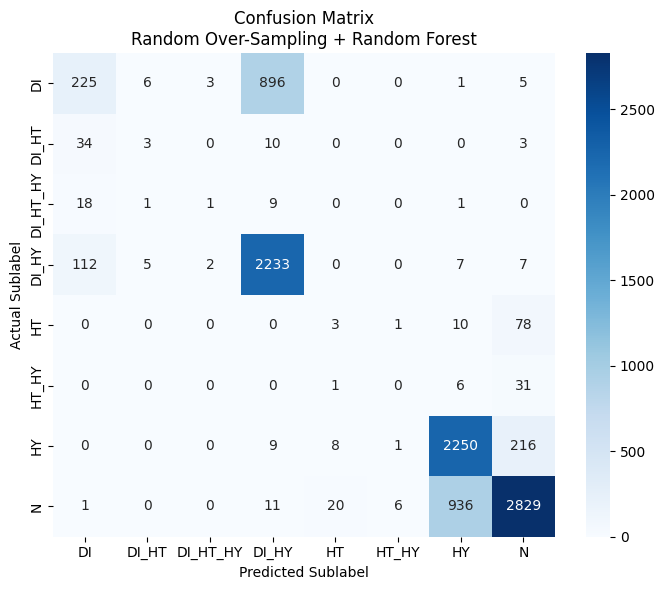

In [55]:
# ============================================================
# 6. CONFUSION MATRIX — FINAL MODEL
# ============================================================

cm = confusion_matrix(
    y_test_raw,
    final_predictions,
    labels=class_names_final
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_final,
    yticklabels=class_names_final
)

plt.title(
    f"Confusion Matrix\n"
    f"{final_sampling_method} + {final_model_name}"
)

plt.xlabel("Predicted Sublabel")
plt.ylabel("Actual Sublabel")

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# 6.1 CLASSIFICATION REPORT
# ============================================================

print("=" * 75)
print("CLASSIFICATION REPORT — FINAL MODEL")
print("=" * 75)

print(
    classification_report(
        y_test_raw,
        final_predictions,
        labels=class_names_final,
        zero_division=0
    )
)

CLASSIFICATION REPORT — FINAL MODEL
              precision    recall  f1-score   support

          DI       0.58      0.20      0.29      1136
       DI_HT       0.20      0.06      0.09        50
    DI_HT_HY       0.17      0.03      0.06        30
       DI_HY       0.70      0.94      0.81      2366
          HT       0.09      0.03      0.05        92
       HT_HY       0.00      0.00      0.00        38
          HY       0.70      0.91      0.79      2484
           N       0.89      0.74      0.81      3803

    accuracy                           0.75      9999
   macro avg       0.42      0.36      0.36      9999
weighted avg       0.75      0.75      0.73      9999



#Improve Accuracy Model Train

#ROC and AUC

ROC CURVE COMPARISON — FOUR MODELS
Sampling Method: Random Over-Sampling
Models: Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting


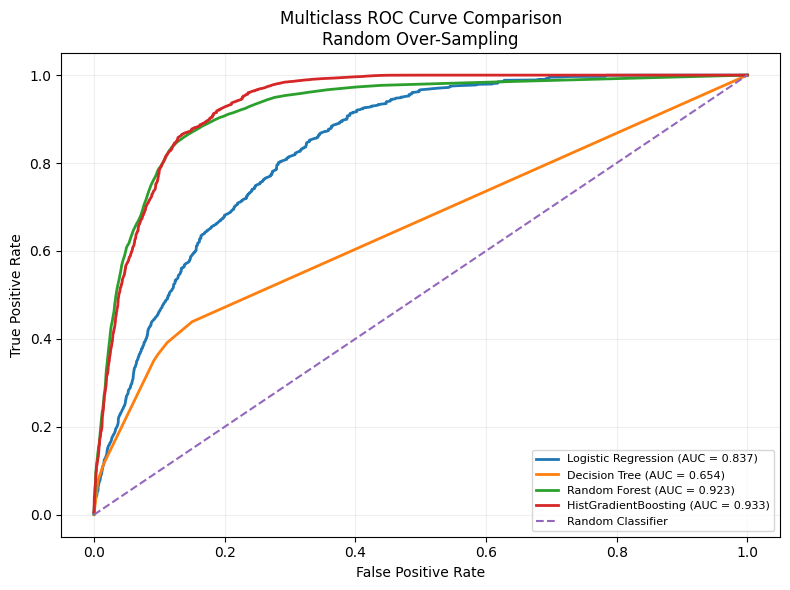

In [57]:
# ============================================================
# 7. ROC CURVE COMPARISON — 4 MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ------------------------------------------------------------
# 1. CLASS ORDER
# ------------------------------------------------------------

class_names = sorted(
    pd.Series(y_test_raw).unique()
)

# Convert actual labels into binary format
y_test_bin = label_binarize(
    y_test_raw,
    classes=class_names
)

# ------------------------------------------------------------
# 2. FOUR MODELS
# ------------------------------------------------------------

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "HistGradientBoosting"
]

# ------------------------------------------------------------
# 3. SELECT SAMPLING METHOD
# ------------------------------------------------------------
# Use the same sampling method selected for the final model

roc_sampling_method = best_sampling_method

print("=" * 80)
print("ROC CURVE COMPARISON — FOUR MODELS")
print("=" * 80)

print("Sampling Method:", roc_sampling_method)
print("Models:", ", ".join(model_names))

# ------------------------------------------------------------
# 4. CALCULATE MACRO-AVERAGE ROC FOR EACH MODEL
# ------------------------------------------------------------

roc_comparison = {}
auc_comparison = {}

for model_name in model_names:

    model = trained_models[
        (roc_sampling_method, model_name)
    ]

    # Prediction probabilities
    y_score = model.predict_proba(
        X_test_encoded
    )

    # Calculate ROC for each class
    fpr = {}
    tpr = {}
    class_auc = {}

    for i, class_name in enumerate(class_names):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        class_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    # --------------------------------------------------------
    # Calculate Macro-Average ROC
    # --------------------------------------------------------

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(len(class_names))]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(class_names)):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(class_names)

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    roc_comparison[model_name] = (
        all_fpr,
        mean_tpr
    )

    auc_comparison[model_name] = macro_auc


# ------------------------------------------------------------
# 5. PLOT ROC CURVES
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name in model_names:

    fpr_macro, tpr_macro = roc_comparison[
        model_name
    ]

    plt.plot(
        fpr_macro,
        tpr_macro,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {auc_comparison[model_name]:.3f})"
        )
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Multiclass ROC Curve Comparison\n"
    f"{roc_sampling_method}"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# 7.1 AUC SUMMARY
# ============================================================

print("=" * 80)
print("7.1 AUC SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# AUC results from Section 7 ROC Curve Comparison
# ------------------------------------------------------------

auc_results = pd.DataFrame({
    "Model": list(auc_comparison.keys()),
    "Macro AUC": list(auc_comparison.values())
})

# ------------------------------------------------------------
# Sort by AUC - highest first
# ------------------------------------------------------------

auc_results = auc_results.sort_values(
    by="Macro AUC",
    ascending=False
).reset_index(drop=True)

# Add ranking
auc_results.insert(
    0,
    "Rank",
    range(1, len(auc_results) + 1)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    auc_results.style.format({
        "Macro AUC": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Best AUC model
# ------------------------------------------------------------

best_auc_model = auc_results.iloc[0]

print("\n" + "=" * 80)
print("BEST AUC MODEL")
print("=" * 80)

print(
    "Model       :",
    best_auc_model["Model"]
)

print(
    f"Macro AUC   : "
    f"{best_auc_model['Macro AUC']:.4f}"
)

print(
    f"Macro AUC   : "
    f"{best_auc_model['Macro AUC']:.2%}"
)

# ------------------------------------------------------------
# Final selected model AUC
# ------------------------------------------------------------

final_model_auc = auc_comparison[
    final_model_name
]

print("\n" + "=" * 80)
print("FINAL MODEL AUC")
print("=" * 80)

print(
    "Sampling Method :",
    final_sampling_method
)

print(
    "Final Model     :",
    final_model_name
)

print(
    f"Macro AUC       : "
    f"{final_model_auc:.4f}"
)

print(
    f"Macro AUC       : "
    f"{final_model_auc:.2%}"
)

7.1 AUC SUMMARY


,Rank,Model,Macro AUC
0,1,HistGradientBoosting,0.9335
1,2,Random Forest,0.9227
2,3,Logistic Regression,0.8367
3,4,Decision Tree,0.6539



BEST AUC MODEL
Model       : HistGradientBoosting
Macro AUC   : 0.9335
Macro AUC   : 93.35%

FINAL MODEL AUC
Sampling Method : Random Over-Sampling
Final Model     : Random Forest
Macro AUC       : 0.9227
Macro AUC       : 92.27%


#Cross Validation

In [59]:
# ============================================================
# CROSS-VALIDATION — 4 MODELS
# Mean Accuracy and Standard Deviation
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Define 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 2. Four Models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42
    )
}

# ------------------------------------------------------------
# 3. Perform Cross-Validation
# ------------------------------------------------------------

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_encoded,
        y_train_raw,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_accuracy = scores.mean()
    std_accuracy = scores.std()

    cv_results.append({
        "Model": model_name,
        "Fold 1 Accuracy": scores[0],
        "Fold 2 Accuracy": scores[1],
        "Fold 3 Accuracy": scores[2],
        "Fold 4 Accuracy": scores[3],
        "Fold 5 Accuracy": scores[4],
        "Mean Accuracy": mean_accuracy,
        "Standard Deviation": std_accuracy
    })

# ------------------------------------------------------------
# 4. Display Results
# ------------------------------------------------------------

cv_results_df = pd.DataFrame(cv_results)

print("=" * 90)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 90)

display(
    cv_results_df.style.format({
        "Fold 1 Accuracy": "{:.4f}",
        "Fold 2 Accuracy": "{:.4f}",
        "Fold 3 Accuracy": "{:.4f}",
        "Fold 4 Accuracy": "{:.4f}",
        "Fold 5 Accuracy": "{:.4f}",
        "Mean Accuracy": "{:.4f}",
        "Standard Deviation": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 5. Best Model Based on Mean Accuracy
# ------------------------------------------------------------

best_cv_row = cv_results_df.loc[
    cv_results_df["Mean Accuracy"].idxmax()
]

print("\nBest Model Based on Mean Accuracy:")
print(f"Model: {best_cv_row['Model']}")
print(f"Mean Accuracy: {best_cv_row['Mean Accuracy']:.4f}")
print(f"Standard Deviation: ±{best_cv_row['Standard Deviation']:.4f}")

5-FOLD CROSS-VALIDATION RESULTS


,Model,Fold 1 Accuracy,Fold 2 Accuracy,Fold 3 Accuracy,Fold 4 Accuracy,Fold 5 Accuracy,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.6456,0.6446,0.6443,0.6387,0.6411,0.6429,0.0026
1,Decision Tree,0.6535,0.6446,0.6475,0.6491,0.6550,0.6499,0.0038
2,Random Forest,0.7613,0.7626,0.7568,0.7643,0.7625,0.7615,0.0025
3,HistGradientBoosting,0.7567,0.7546,0.7517,0.7577,0.7578,0.7557,0.0023



Best Model Based on Mean Accuracy:
Model: Random Forest
Mean Accuracy: 0.7615
Standard Deviation: ±0.0025


In [60]:
# ============================================================
# 8.1 STABILITY AND GENERALIZATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

print("=" * 80)
print("8.1 STABILITY AND GENERALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Create 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 2. Create preprocessing
# ------------------------------------------------------------

cv_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# 3. Select final sampling method
# ------------------------------------------------------------

if final_sampling_method == "Random Over-Sampling":

    sampler = RandomOverSampler(
        random_state=42
    )

elif final_sampling_method == "SMOTE":

    sampler = SMOTE(
        random_state=42,
        k_neighbors=5
    )

else:

    raise ValueError(
        f"Unknown sampling method: {final_sampling_method}"
    )

# ------------------------------------------------------------
# 4. Create the selected final model
# ------------------------------------------------------------

if final_model_name == "Logistic Regression":

    cv_model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

elif final_model_name == "Decision Tree":

    cv_model = DecisionTreeClassifier(
        random_state=42
    )

elif final_model_name == "Random Forest":

    cv_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

elif final_model_name == "HistGradientBoosting":

    cv_model = HistGradientBoostingClassifier(
        random_state=42
    )

else:

    raise ValueError(
        f"Unknown model: {final_model_name}"
    )

# ------------------------------------------------------------
# 5. Create pipeline
# ------------------------------------------------------------

cv_pipeline = ImbPipeline(
    steps=[
        ("preprocessing", cv_preprocessor),
        ("sampling", sampler),
        ("model", cv_model)
    ]
)

# ------------------------------------------------------------
# 6. Cross-validation metrics
# ------------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

# ------------------------------------------------------------
# 7. Run 5-Fold Cross-Validation
# ------------------------------------------------------------

cv_scores = cross_validate(
    cv_pipeline,
    X_train_raw,
    y_train_raw,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

# ------------------------------------------------------------
# 8. Calculate CV Accuracy
# ------------------------------------------------------------

cv_mean_accuracy = cv_scores["test_accuracy"].mean()

cv_std_accuracy = cv_scores["test_accuracy"].std()

# ------------------------------------------------------------
# 9. Final Test Accuracy
# ------------------------------------------------------------

final_test_accuracy = accuracy_score(
    y_test_raw,
    final_predictions
)

# ------------------------------------------------------------
# 10. Generalization Gap
# ------------------------------------------------------------

generalization_gap = abs(
    final_test_accuracy - cv_mean_accuracy
)

# ------------------------------------------------------------
# 11. Stability Interpretation
# ------------------------------------------------------------

if cv_std_accuracy <= 0.01:

    stability = "Very Stable"

elif cv_std_accuracy <= 0.02:

    stability = "Stable"

elif cv_std_accuracy <= 0.05:

    stability = "Moderately Stable"

else:

    stability = "Unstable"

# ------------------------------------------------------------
# 12. Generalization Interpretation
# ------------------------------------------------------------

if generalization_gap <= 0.02:

    generalization = "Strong"

elif generalization_gap <= 0.05:

    generalization = "Acceptable"

else:

    generalization = "Concern"

# ------------------------------------------------------------
# 13. Create Result Table
# ------------------------------------------------------------

stability_result = pd.DataFrame({

    "Model": [
        final_model_name
    ],

    "Sampling Method": [
        final_sampling_method
    ],

    "Test Accuracy": [
        final_test_accuracy
    ],

    "CV Mean Accuracy": [
        cv_mean_accuracy
    ],

    "CV Std. Deviation": [
        cv_std_accuracy
    ],

    "Generalization Gap": [
        generalization_gap
    ],

    "Stability": [
        stability
    ],

    "Generalization": [
        generalization
    ]
})

# ------------------------------------------------------------
# 14. Display Results
# ------------------------------------------------------------

display(
    stability_result.style.format({
        "Test Accuracy": "{:.2%}",
        "CV Mean Accuracy": "{:.2%}",
        "CV Std. Deviation": "±{:.2%}",
        "Generalization Gap": "{:.2%}"
    })
)

# ------------------------------------------------------------
# 15. Findings
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINDINGS")
print("=" * 80)

print(
    f"Final Model       : {final_model_name}"
)

print(
    f"Sampling Method   : {final_sampling_method}"
)

print(
    f"Test Accuracy     : {final_test_accuracy:.2%}"
)

print(
    f"CV Mean Accuracy  : {cv_mean_accuracy:.2%}"
)

print(
    f"CV Std. Deviation : ±{cv_std_accuracy:.2%}"
)

print(
    f"Generalization Gap: {generalization_gap:.2%}"
)

print(
    f"Stability         : {stability}"
)

print(
    f"Generalization    : {generalization}"
)

print("\nInterpretation:")

print(
    f"The final {final_model_name} model using "
    f"{final_sampling_method} achieved a test accuracy of "
    f"{final_test_accuracy:.2%}. "
    f"Across five stratified folds, the mean cross-validation "
    f"accuracy was {cv_mean_accuracy:.2%} with a standard "
    f"deviation of ±{cv_std_accuracy:.2%}."
)

print(
    f"The difference between the test accuracy and the "
    f"cross-validation mean is {generalization_gap:.2%}, "
    f"indicating {generalization.lower()} generalization."
)

8.1 STABILITY AND GENERALIZATION


,Model,Sampling Method,Test Accuracy,CV Mean Accuracy,CV Std. Deviation,Generalization Gap,Stability,Generalization
0,Random Forest,Random Over-Sampling,75.45%,75.87%,±0.24%,0.42%,Very Stable,Strong



FINDINGS
Final Model       : Random Forest
Sampling Method   : Random Over-Sampling
Test Accuracy     : 75.45%
CV Mean Accuracy  : 75.87%
CV Std. Deviation : ±0.24%
Generalization Gap: 0.42%
Stability         : Very Stable
Generalization    : Strong

Interpretation:
The final Random Forest model using Random Over-Sampling achieved a test accuracy of 75.45%. Across five stratified folds, the mean cross-validation accuracy was 75.87% with a standard deviation of ±0.24%.
The difference between the test accuracy and the cross-validation mean is 0.42%, indicating strong generalization.


#Final Prediction Example

In [61]:
# ============================================================
# 9. FINAL PREDICTION EXAMPLE
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print("=" * 80)
print("9. FINAL PREDICTION EXAMPLE")
print("=" * 80)


# ============================================================
# 1. GET FINAL MODEL
# ============================================================

final_sampling_method = best_sampling_method
final_model_name = best_sampling_model_name

# Get the ACTUAL trained model, not the model name string
final_model = trained_models[
    (final_sampling_method, final_model_name)
]

print("Final Sampling Method :", final_sampling_method)
print("Final Model           :", final_model_name)


# ============================================================
# 2. EXAMPLE INPUT
# ============================================================

new_data = pd.DataFrame([{

    # --------------------------------------------------------
    # Categorical features
    # --------------------------------------------------------

    "gender": "Male",
    "smoking": "Never",
    "physical_activity": "Low",
    "family_history": "Yes",
    "stress_level": "High",
    "sugar_consumption": "High",
    "education_level": "Tertiary",
    "employment_status": "Employed",

    # --------------------------------------------------------
    # Numerical features
    # --------------------------------------------------------

    "age": 55,
    "bmi": 29.4,
    "HbA1c_level": 7.2,
    "glucose": 145,
    "cholesterol": 220,
    "sleep_hours": 6.5,
    "triglycerides": 180,
    "blood_pressure": 145,
    "crp_level": 4.5,
    "homocysteine_level": 14.2,
    "alcohol_intake": 0,
    "salt_intake": 1,
    "heart_rate": 82,
    "hdl": 42,
    "ldl": 142

}])


# ============================================================
# 3. MATCH EXACT TRAINING COLUMN ORDER
# ============================================================

missing_columns = [
    col for col in X_train_raw.columns
    if col not in new_data.columns
]

extra_columns = [
    col for col in new_data.columns
    if col not in X_train_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing input features: {missing_columns}"
    )

if extra_columns:
    print(
        "Ignoring extra input features:",
        extra_columns
    )

new_data = new_data[
    X_train_raw.columns
].copy()


# ============================================================
# 4. CREATE A FRESH PREPROCESSOR
#    FIT ONLY ON TRAINING DATA
# ============================================================

prediction_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 5. FIT PREPROCESSOR ON TRAINING DATA
# ============================================================

prediction_preprocessor.fit(
    X_train_raw
)


# ============================================================
# 6. TRANSFORM NEW INPUT
# ============================================================

new_data_processed = (
    prediction_preprocessor.transform(
        new_data
    )
)

new_data_processed = np.asarray(
    new_data_processed,
    dtype=np.float64
)


# ============================================================
# 7. FEATURE CHECK
# ============================================================

print("\n" + "=" * 80)
print("FINAL PREDICTION FEATURE CHECK")
print("=" * 80)

print(
    "Original input features :",
    new_data.shape[1]
)

print(
    "Processed input features:",
    new_data_processed.shape[1]
)

print(
    "Model expects features  :",
    final_model.n_features_in_
)


if (
    new_data_processed.shape[1]
    != final_model.n_features_in_
):

    raise ValueError(
        f"\nFeature mismatch!\n"
        f"Processed input has "
        f"{new_data_processed.shape[1]} features, "
        f"but the model expects "
        f"{final_model.n_features_in_} features."
    )

print("\n✓ Feature dimensions match.")


# ============================================================
# 8. FINAL PREDICTION
# ============================================================

predicted_class = final_model.predict(
    new_data_processed
)[0]


# ============================================================
# 9. PREDICTION PROBABILITIES
# ============================================================

if hasattr(final_model, "predict_proba"):

    probabilities = (
        final_model.predict_proba(
            new_data_processed
        )[0]
    )

    probability_df = pd.DataFrame({

        "Sublabel": final_model.classes_,

        "Probability (%)":
            probabilities * 100

    }).sort_values(
        by="Probability (%)",
        ascending=False
    ).reset_index(drop=True)

else:

    probability_df = None


# ============================================================
# 10. DISPLAY FINAL RESULT
# ============================================================

print("\n" + "=" * 80)
print("FINAL PREDICTION")
print("=" * 80)

print(
    "Sampling Method:",
    final_sampling_method
)

print(
    "Model:",
    final_model_name
)

print(
    "\nPredicted Sublabel:",
    predicted_class
)


# ============================================================
# 11. DISPLAY PROBABILITIES
# ============================================================

if probability_df is not None:

    print("\nPrediction Probabilities:")

    display(
        probability_df.style.format({
            "Probability (%)": "{:.2f}%"
        })
    )


# ============================================================
# 12. DISPLAY INPUT DATA
# ============================================================

print("\n" + "=" * 80)
print("INPUT FEATURES USED FOR PREDICTION")
print("=" * 80)

display(new_data.T)

9. FINAL PREDICTION EXAMPLE
Final Sampling Method : Random Over-Sampling
Final Model           : Random Forest

FINAL PREDICTION FEATURE CHECK
Original input features : 23
Processed input features: 37
Model expects features  : 37

✓ Feature dimensions match.

FINAL PREDICTION
Sampling Method: Random Over-Sampling
Model: Random Forest

Predicted Sublabel: DI_HY

Prediction Probabilities:


,Sublabel,Probability (%)
0,DI_HY,69.00%
1,DI,27.50%
2,HY,2.00%
3,DI_HT,1.00%
4,N,0.50%
5,DI_HT_HY,0.00%
6,HT_HY,0.00%
7,HT,0.00%



INPUT FEATURES USED FOR PREDICTION


,0
gender,Male
smoking,Never
age,55
bmi,29.4
HbA1c_level,7.2
glucose,145
cholesterol,220
sleep_hours,6.5
triglycerides,180
physical_activity,Low


#Interactive UI

In [85]:
# ============================================================
# 10. INTERACTIVE FINAL PREDICTION UI
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# FEATURE LIST
# ============================================================

categorical_features_ui = (
    categorical_features_model
)

numerical_features_ui = (
    numerical_features_model
)


# ============================================================
# CREATE INPUT WIDGETS
# ============================================================

input_widgets = {}


# ------------------------------------------------------------
# Categorical widgets
# ------------------------------------------------------------

for col in categorical_features_ui:

    categories = sorted(
        X_model[col]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    input_widgets[col] = widgets.Dropdown(
        options=categories,
        value=categories[0],
        description=f"{col}:",
        layout=widgets.Layout(width="450px")
    )


# ------------------------------------------------------------
# Numerical widgets
# ------------------------------------------------------------

for col in numerical_features_ui:

    median_value = float(
        pd.to_numeric(
            X_model[col],
            errors="coerce"
        ).median()
    )

    input_widgets[col] = widgets.FloatText(
        value=median_value,
        description=f"{col}:",
        layout=widgets.Layout(width="450px")
    )


# ============================================================
# PREDICT BUTTON
# ============================================================

predict_button = widgets.Button(
    description="Predict Sublabel",
    button_style="success",
    layout=widgets.Layout(
        width="220px",
        height="45px"
    )
)

output = widgets.Output()


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_from_ui(button):

    with output:

        clear_output()

        try:

            # ------------------------------------------------
            # Collect user inputs
            # ------------------------------------------------

            user_input = {}

            for col in X_train_raw.columns:

                value = input_widgets[col].value

                user_input[col] = value


            # ------------------------------------------------
            # Create DataFrame
            # ------------------------------------------------

            user_df = pd.DataFrame(
                [user_input]
            )


            # ------------------------------------------------
            # Correct column order
            # ------------------------------------------------

            user_df = user_df[
                X_train_raw.columns
            ]


            # ------------------------------------------------
            # Transform
            # ------------------------------------------------

            user_processed = (
                preprocessor_sampling.transform(
                    user_df
                )
            )

            user_processed = np.asarray(
                user_processed,
                dtype=np.float64
            )


            # ------------------------------------------------
            # Check dimensions
            # ------------------------------------------------

            if (
                user_processed.shape[1]
                != final_model.n_features_in_
            ):

                raise ValueError(
                    f"Feature mismatch: "
                    f"processed input has "
                    f"{user_processed.shape[1]} features, "
                    f"but model expects "
                    f"{final_model.n_features_in_}."
                )


            # ------------------------------------------------
            # Predict
            # ------------------------------------------------

            prediction = final_model.predict(
                user_processed
            )[0]


            # ------------------------------------------------
            # Probabilities
            # ------------------------------------------------

            probabilities = (
                final_model.predict_proba(
                    user_processed
                )[0]
            )


            probability_df = pd.DataFrame({

                "Sublabel":
                    final_model.classes_,

                "Probability (%)":
                    probabilities * 100

            }).sort_values(
                "Probability (%)",
                ascending=False
            ).reset_index(drop=True)


            # ------------------------------------------------
            # Display
            # ------------------------------------------------

            print("=" * 65)
            print("FINAL PREDICTION RESULT")
            print("=" * 65)

            print(
                f"Sampling Method: "
                f"{final_sampling_method}"
            )

            print(
                f"Final Model: "
                f"{final_model_name}"
            )

            print(
                f"\nPredicted Sublabel: "
                f"{prediction}"
            )

            print(
                "\nClass Probabilities:"
            )

            display(
                probability_df.style.format({
                    "Probability (%)":
                        "{:.2f}%"
                })
            )


        except Exception as e:

            print(
                "Prediction Error:"
            )

            print(
                str(e)
            )


predict_button.on_click(
    predict_from_ui
)


# ============================================================
# UI LAYOUT
# ============================================================

categorical_box = widgets.VBox(
    [
        widgets.HTML(
            "<h3>Categorical Features</h3>"
        )
    ]
    +
    [
        input_widgets[col]
        for col in categorical_features_ui
    ]
)


numerical_box = widgets.VBox(
    [
        widgets.HTML(
            "<h3>Numerical Features</h3>"
        )
    ]
    +
    [
        input_widgets[col]
        for col in numerical_features_ui
    ]
)


display(
    widgets.VBox([
        widgets.HTML(
            "<h1>Final Sublabel Prediction</h1>"
        ),

        widgets.HTML(
            f"<b>Final Model:</b> "
            f"{final_model_name}"
        ),

        widgets.HTML(
            f"<b>Sampling:</b> "
            f"{final_sampling_method}"
        ),

        categorical_box,

        numerical_box,

        widgets.HTML("<br>"),

        predict_button,

        output

    ])
)

#(4) Second Prediction

In [69]:
# ============================================================
# BINARY LABEL PREDICTION — 1. FEATURE SELECTION
# Target: label (Binary Classification)
# ============================================================

import pandas as pd
import numpy as np

# Keep only rows with a known binary label
data_label = df.dropna(subset=["label"]).copy()

# These are the original 23 project input features.
# Target-related, derived, redundant, and alternative-label
# columns are deliberately excluded to prevent data leakage.
label_features = [
    "gender",
    "smoking",
    "age",
    "bmi",
    "HbA1c_level",
    "glucose",
    "cholesterol",
    "sleep_hours",
    "triglycerides",
    "physical_activity",
    "family_history",
    "stress_level",
    "blood_pressure",
    "sugar_consumption",
    "crp_level",
    "homocysteine_level",
    "alcohol_intake",
    "salt_intake",
    "heart_rate",
    "hdl",
    "ldl",
    "education_level",
    "employment_status"
]

# Explicitly excluded columns for leakage prevention
excluded_label_columns = [
    "label",
    "sublabel",
    "disease_flags",
    "diabetes",
    "hypertension",
    "heart_disease",
    "age_level",
    "age_normalized",
    "bmi_level",
    "low_hdl_cholesterol",
    "high_ldl_cholesterol",
    "high_blood_pressure",
    "systolic_bp",
    "diastolic_bp"
]

X_label = data_label[label_features].copy()
y_label = data_label["label"].copy()

print("=" * 80)
print("BINARY LABEL — FEATURE SELECTION")
print("=" * 80)

print("Target variable:", "label")
print("Target classes:", sorted(y_label.unique().tolist()))
print("Number of records:", len(data_label))
print("Number of input features:", X_label.shape[1])

print("\nExcluded target/leakage-related columns:")
print(excluded_label_columns)


print("Input features used:")
print(label_features)


print("Binary label distribution:")
display(
    y_label.value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

BINARY LABEL — FEATURE SELECTION
Target variable: label
Target classes: ['Abnormal', 'Normal']
Number of records: 47457
Number of input features: 23

Excluded target/leakage-related columns:
['label', 'sublabel', 'disease_flags', 'diabetes', 'hypertension', 'heart_disease', 'age_level', 'age_normalized', 'bmi_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'systolic_bp', 'diastolic_bp']
Input features used:
['gender', 'smoking', 'age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status']
Binary label distribution:


,Label,Count
0,Abnormal,29447
1,Normal,18010


In [70]:
# ============================================================
# BINARY LABEL PREDICTION — 2. TRAIN-TEST SPLIT + PREPROCESSING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify categorical and numerical features
label_categorical_features = X_label.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

label_numerical_features = [
    col for col in X_label.columns
    if col not in label_categorical_features
]

# Stratified split preserves the binary class distribution
X_label_train_raw, X_label_test_raw, y_label_train, y_label_test = train_test_split(
    X_label,
    y_label,
    test_size=0.20,
    random_state=42,
    stratify=y_label
)

# Preprocessing:
# - categorical: most-frequent imputation + one-hot encoding
# - numerical: median imputation
label_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            label_categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            label_numerical_features
        )
    ],
    remainder="drop"
)

# FIT ONLY on training data
X_label_train_encoded = label_preprocessor.fit_transform(
    X_label_train_raw
)

# Transform test data using the already-fitted transformer
X_label_test_encoded = label_preprocessor.transform(
    X_label_test_raw
)

X_label_train_encoded = np.asarray(
    X_label_train_encoded,
    dtype=np.float64
)

X_label_test_encoded = np.asarray(
    X_label_test_encoded,
    dtype=np.float64
)

print("=" * 80)
print("BINARY LABEL — PREPROCESSING")
print("=" * 80)

print("Training records:", X_label_train_encoded.shape[0])
print("Testing records :", X_label_test_encoded.shape[0])
print("Encoded features:", X_label_train_encoded.shape[1])
print("Categorical features:", label_categorical_features)
print("Numerical features:", label_numerical_features)

BINARY LABEL — PREPROCESSING
Training records: 37965
Testing records : 9492
Encoded features: 37
Categorical features: ['gender', 'smoking', 'physical_activity', 'family_history', 'stress_level', 'sugar_consumption', 'education_level', 'employment_status']
Numerical features: ['age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']


In [71]:
# ============================================================
# BINARY LABEL PREDICTION — 3. ROS + SMOTE
# ============================================================

from imblearn.over_sampling import RandomOverSampler, SMOTE

# -------------------------
# Random Over-Sampling
# -------------------------
label_ros = RandomOverSampler(random_state=42)

X_label_train_ros, y_label_train_ros = label_ros.fit_resample(
    X_label_train_encoded,
    y_label_train
)

# -------------------------
# SMOTE
# -------------------------
label_smote = SMOTE(random_state=42)

X_label_train_smote, y_label_train_smote = label_smote.fit_resample(
    X_label_train_encoded,
    y_label_train
)

print("=" * 80)
print("BINARY LABEL — SAMPLING RESULTS")
print("=" * 80)

print("\nOriginal training distribution:")
display(
    pd.Series(y_label_train)
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

print("\nAfter Random Over-Sampling:")
display(
    pd.Series(y_label_train_ros)
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

print("\nAfter SMOTE:")
display(
    pd.Series(y_label_train_smote)
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)


BINARY LABEL — SAMPLING RESULTS

Original training distribution:


,Label,Count
0,Abnormal,23557
1,Normal,14408



After Random Over-Sampling:


,Label,Count
0,Abnormal,23557
1,Normal,23557



After SMOTE:


,Label,Count
0,Abnormal,23557
1,Normal,23557


In [72]:
# ============================================================
# BINARY LABEL PREDICTION — 4. MODEL TRAINING
# 4 MODELS × 2 SAMPLING METHODS
# ============================================================

import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

label_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=300,
        solver="liblinear",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42
    )
}

label_sampling_data = {
    "Random Over-Sampling": (
        X_label_train_ros,
        y_label_train_ros
    ),
    "SMOTE": (
        X_label_train_smote,
        y_label_train_smote
    )
}

label_results = []
label_trained_models = {}
label_predictions = {}
label_probabilities = {}

for sampling_name, (X_sampled, y_sampled) in label_sampling_data.items():

    print("\n" + "=" * 80)
    print("TRAINING WITH:", sampling_name)
    print("=" * 80)

    for model_name, model_template in label_models.items():

        print(f"Training {model_name}...")
        start_time = time.time()

        model = model_template.fit(
            X_sampled,
            y_sampled
        )

        training_time = time.time() - start_time

        # Predict on untouched test data
        y_pred = model.predict(
            X_label_test_encoded
        )


        accuracy = accuracy_score(
            y_label_test,
            y_pred
        )

        precision = precision_score(
            y_label_test,
            y_pred,
            average="binary",
            pos_label="Abnormal",
            zero_division=0
        )

        recall = recall_score(
            y_label_test,
            y_pred,
            average="binary",
            pos_label="Abnormal",
            zero_division=0
        )

        f1 = f1_score(
            y_label_test,
            y_pred,
            average="binary",
            pos_label="Abnormal",
            zero_division=0
        )

        # ROC-AUC for the binary target
        positive_class_index = list(model.classes_).index("Abnormal")

        y_prob_positive = model.predict_proba(
            X_label_test_encoded
        )[:, positive_class_index]

        auc_score = roc_auc_score(
            (y_label_test == "Abnormal").astype(int),
            y_prob_positive
        )

        label_results.append({
            "Sampling Method": sampling_name,
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "AUC-ROC": auc_score,
            "Training Time (s)": training_time
        })

        label_trained_models[
            (sampling_name, model_name)
        ] = model

        label_predictions[
            (sampling_name, model_name)
        ] = y_pred

        label_probabilities[
            (sampling_name, model_name)
        ] = y_prob_positive

        print(
            f"Accuracy={accuracy:.4f}, "
            f"F1={f1:.4f}, "
            f"AUC={auc_score:.4f}"
        )

label_results_df = pd.DataFrame(label_results)

print("\n" + "=" * 80)
print("BINARY LABEL MODEL TRAINING COMPLETED")
print("=" * 80)

display(
    label_results_df.sort_values(
        by=["Accuracy", "F1-Score", "AUC-ROC"],
        ascending=False
    ).reset_index(drop=True).style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}",
        "AUC-ROC": "{:.3f}",
        "Training Time (s)": "{:.2f}"
    })
)



TRAINING WITH: Random Over-Sampling
Training Logistic Regression...
Accuracy=0.7509, F1=0.7884, AUC=0.8474
Training Decision Tree...
Accuracy=0.8143, F1=0.8497, AUC=0.8042
Training Random Forest...
Accuracy=0.8767, F1=0.9057, AUC=0.9357
Training HistGradientBoosting...
Accuracy=0.8705, F1=0.8991, AUC=0.9352

TRAINING WITH: SMOTE
Training Logistic Regression...
Accuracy=0.7492, F1=0.7871, AUC=0.8468
Training Decision Tree...
Accuracy=0.8092, F1=0.8449, AUC=0.8004
Training Random Forest...
Accuracy=0.8764, F1=0.9055, AUC=0.9355
Training HistGradientBoosting...
Accuracy=0.8761, F1=0.9046, AUC=0.9342

BINARY LABEL MODEL TRAINING COMPLETED


,Sampling Method,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
0,Random Over-Sampling,Random Forest,87.67%,86.20%,95.42%,90.57%,0.936,17.16
1,SMOTE,Random Forest,87.64%,86.12%,95.47%,90.55%,0.935,22.94
2,SMOTE,HistGradientBoosting,87.61%,86.64%,94.62%,90.46%,0.934,2.27
3,Random Over-Sampling,HistGradientBoosting,87.05%,87.02%,93.01%,89.91%,0.935,1.86
4,Random Over-Sampling,Decision Tree,81.43%,85.33%,84.62%,84.97%,0.804,0.84
5,SMOTE,Decision Tree,80.92%,85.23%,83.77%,84.49%,0.800,1.09
6,Random Over-Sampling,Logistic Regression,75.09%,83.36%,74.79%,78.84%,0.847,37.23
7,SMOTE,Logistic Regression,74.92%,83.15%,74.72%,78.71%,0.847,36.74


In [73]:
# ============================================================
# BINARY LABEL PREDICTION — 5. BEST MODEL SELECTION
# ============================================================

label_results_sorted = label_results_df.sort_values(
    by=["Accuracy", "F1-Score", "AUC-ROC"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_label_result = label_results_sorted.iloc[0]

best_label_sampling_method = best_label_result["Sampling Method"]
best_label_model_name = best_label_result["Model"]

best_label_model = label_trained_models[
    (best_label_sampling_method, best_label_model_name)
]

best_label_predictions = label_predictions[
    (best_label_sampling_method, best_label_model_name)
]

best_label_probabilities = label_probabilities[
    (best_label_sampling_method, best_label_model_name)
]

print("=" * 80)
print("FINAL BINARY LABEL MODEL SELECTION")
print("=" * 80)

print("Target               :", "label")
print("Sampling Method      :", best_label_sampling_method)
print("Best Model           :", best_label_model_name)
print(f"Accuracy             : {best_label_result['Accuracy']:.2%}")
print(f"Precision            : {best_label_result['Precision']:.2%}")
print(f"Recall               : {best_label_result['Recall']:.2%}")
print(f"F1-Score             : {best_label_result['F1-Score']:.2%}")
print(f"AUC-ROC              : {best_label_result['AUC-ROC']:.3f}")

print("\nAll model/sampling combinations:")
display(
    label_results_sorted.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}",
        "AUC-ROC": "{:.3f}",
        "Training Time (s)": "{:.2f}"
    })
)


FINAL BINARY LABEL MODEL SELECTION
Target               : label
Sampling Method      : Random Over-Sampling
Best Model           : Random Forest
Accuracy             : 87.67%
Precision            : 86.20%
Recall               : 95.42%
F1-Score             : 90.57%
AUC-ROC              : 0.936

All model/sampling combinations:


,Sampling Method,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
0,Random Over-Sampling,Random Forest,87.67%,86.20%,95.42%,90.57%,0.936,17.16
1,SMOTE,Random Forest,87.64%,86.12%,95.47%,90.55%,0.935,22.94
2,SMOTE,HistGradientBoosting,87.61%,86.64%,94.62%,90.46%,0.934,2.27
3,Random Over-Sampling,HistGradientBoosting,87.05%,87.02%,93.01%,89.91%,0.935,1.86
4,Random Over-Sampling,Decision Tree,81.43%,85.33%,84.62%,84.97%,0.804,0.84
5,SMOTE,Decision Tree,80.92%,85.23%,83.77%,84.49%,0.800,1.09
6,Random Over-Sampling,Logistic Regression,75.09%,83.36%,74.79%,78.84%,0.847,37.23
7,SMOTE,Logistic Regression,74.92%,83.15%,74.72%,78.71%,0.847,36.74


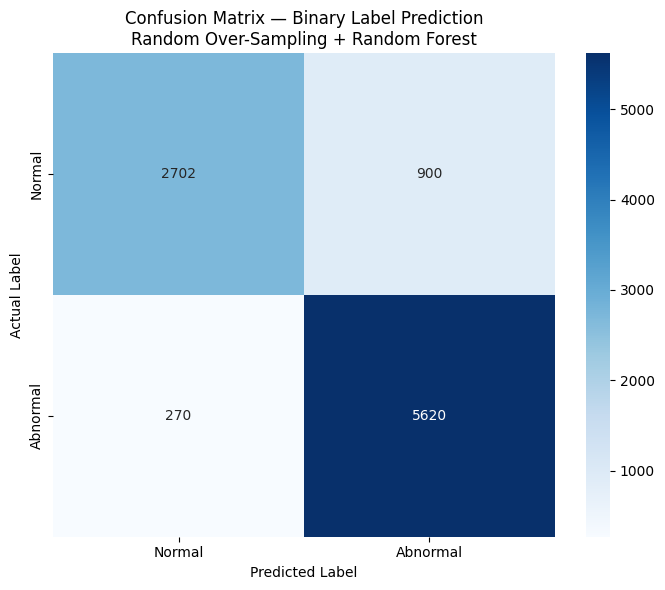


Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.75      0.82      3602
    Abnormal       0.86      0.95      0.91      5890

    accuracy                           0.88      9492
   macro avg       0.89      0.85      0.86      9492
weighted avg       0.88      0.88      0.87      9492



In [74]:
# ============================================================
# BINARY LABEL PREDICTION — 6. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

label_class_names = ["Normal", "Abnormal"]

cm_label = confusion_matrix(
    y_label_test,
    best_label_predictions,
    labels=label_class_names
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_label,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_class_names,
    yticklabels=label_class_names
)

plt.title(
    f"Confusion Matrix — Binary Label Prediction\n"
    f"{best_label_sampling_method} + {best_label_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_label_test,
        best_label_predictions,
        labels=label_class_names,
        zero_division=0
    )
)


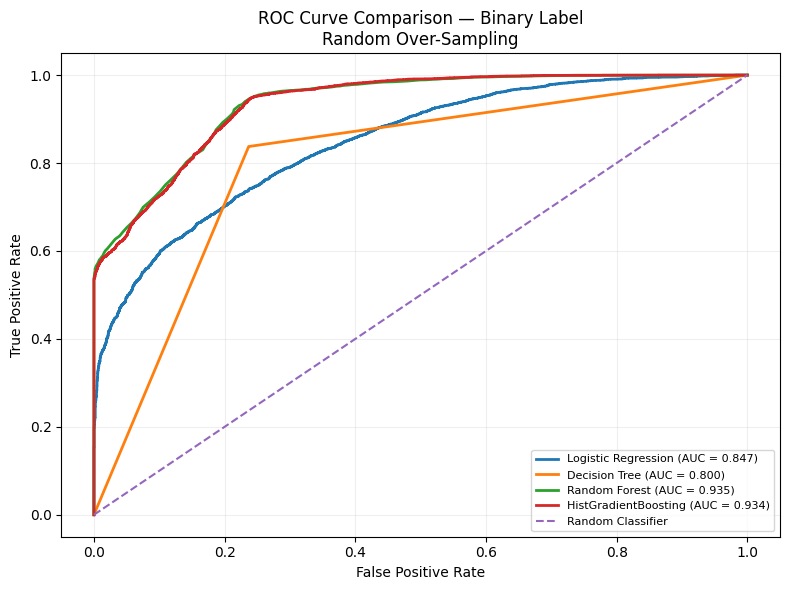


AUC-ROC Summary:


,Model,AUC-ROC
0,Random Forest,0.935
1,HistGradientBoosting,0.934
2,Logistic Regression,0.847
3,Decision Tree,0.800


In [75]:
# ============================================================
# BINARY LABEL PREDICTION — 7. ROC CURVE
# 4 MODELS USING THE SELECTED SAMPLING METHOD
# ============================================================

from sklearn.metrics import roc_curve, auc

roc_label_sampling = best_label_sampling_method

plt.figure(figsize=(8, 6))

label_auc_results = {}

for model_name in label_models.keys():

    model = label_trained_models[
        (roc_label_sampling, model_name)
    ]

    positive_class_index = list(model.classes_).index("Abnormal")

    y_score = model.predict_proba(
        X_label_test_encoded
    )[:, positive_class_index]

    y_binary = (
        y_label_test == "Abnormal"
    ).astype(int)

    fpr, tpr, _ = roc_curve(
        y_binary,
        y_score
    )

    model_auc = auc(
        fpr,
        tpr
    )

    label_auc_results[model_name] = model_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve Comparison — Binary Label\n"
    f"{roc_label_sampling}"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

label_auc_df = pd.DataFrame({
    "Model": list(label_auc_results.keys()),
    "AUC-ROC": list(label_auc_results.values())
}).sort_values(
    "AUC-ROC",
    ascending=False
).reset_index(drop=True)

print("\nAUC-ROC Summary:")
display(
    label_auc_df.style.format({
        "AUC-ROC": "{:.3f}"
    })
)


In [76]:
# ============================================================
# BINARY LABEL PREDICTION — 8. FINAL PREDICTION EXAMPLE
# ============================================================

# Example input using only the 23 allowed prediction features
new_label_input = pd.DataFrame([{
    "gender": "Male",
    "smoking": "Never",
    "age": 55,
    "bmi": 29.4,
    "HbA1c_level": 5.5,
    "glucose": 110,
    "cholesterol": 210,
    "sleep_hours": 7.0,
    "triglycerides": 150,
    "physical_activity": "Moderate",
    "family_history": "No",
    "stress_level": "Medium",
    "blood_pressure": 125,
    "sugar_consumption": "Low",
    "crp_level": 3.0,
    "homocysteine_level": 12.0,
    "alcohol_intake": 5.0,
    "salt_intake": 6.0,
    "heart_rate": 72,
    "hdl": 55,
    "ldl": 120,
    "education_level": "Tertiary",
    "employment_status": "Employed"
}])

# Match exact training feature order
new_label_input = new_label_input[
    label_features
].copy()

# Transform using the preprocessor fitted ONLY on training data
new_label_processed = label_preprocessor.transform(
    new_label_input
)

new_label_processed = np.asarray(
    new_label_processed,
    dtype=np.float64
)

# Final prediction
predicted_label = best_label_model.predict(
    new_label_processed
)[0]

print("=" * 80)
print("FINAL BINARY LABEL PREDICTION")
print("=" * 80)

print("Sampling Method :", best_label_sampling_method)
print("Model           :", best_label_model_name)
print("Predicted Label :", predicted_label)

# Probability for both classes
if hasattr(best_label_model, "predict_proba"):

    class_probabilities = best_label_model.predict_proba(
        new_label_processed
    )[0]

    label_probability_df = pd.DataFrame({
        "Label": best_label_model.classes_,
        "Probability (%)": class_probabilities * 100
    }).sort_values(
        "Probability (%)",
        ascending=False
    ).reset_index(drop=True)

    print("\nPrediction Probabilities:")
    display(
        label_probability_df.style.format({
            "Probability (%)": "{:.2f}%"
        })
    )

print("\nInput features used:")
display(new_label_input.T)


FINAL BINARY LABEL PREDICTION
Sampling Method : Random Over-Sampling
Model           : Random Forest
Predicted Label : Abnormal

Prediction Probabilities:


,Label,Probability (%)
0,Abnormal,70.50%
1,Normal,29.50%



Input features used:


,0
gender,Male
smoking,Never
age,55
bmi,29.4
HbA1c_level,5.5
glucose,110
cholesterol,210
sleep_hours,7.0
triglycerides,150
physical_activity,Moderate
